# **TP 2 - Grupo:**

- Leonardo Felipe Sarmento dos Reis :  leonardo.freis@al.infnet.edu.br
- Luana Martins Ferreira : luana.ferreira@al.infnet.edu.br
- Luiz Felipe Donizeti Machado : luiz.fmachado@al.infnet.edu.br

# **Link de fonte do Dataset**
https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset/data

# **Documentação**

## **Fonte (origem do dataset):**
O dataset não contém informações de sua origem. Devido aos dados presentes, parece tratar-se de um dataset fictício.

## **Principais características:**
Dados do cliente: nome, e-mail, idade e gênero.
Produto: 42 produtos diferentes.
Informações do chamado: tipo, assunto, descrição, status, prioridade e canal.
Atendimento: primeira resposta, resolução, tempo até a resolução e satisfação.

## **Motivo de escolha do dataset:**
Esse dataset serve, principalmente, para estudar e testar técnicas de análise de dados aplicadas a atendimento ao cliente (Customer Support)


# **Compreensão do problema e do dataset**

Classificar automáticamente a intenção de uma mensagem enviada pelo cliente

# **Inicialização do DataFrame**

In [115]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.feature_extraction.text import CountVectorizer
from itertools import combinations
from scipy import stats
from sklearn.feature_selection import chi2
from sklearn.metrics.pairwise import cosine_similarity


def print_formatado(*args, prefixo=5, largura_total=100):
    titulo = " ".join(str(a) for a in args)
    print("\n")
    print("=" * 100)
    print(titulo)
    print("=" * 100)

df = pd.read_csv('customer_support_tickets.csv')

variaveis_numericas = ['Ticket ID', 'Customer Age', 'Customer Satisfaction Rating']
variaveis_temporais = ['Date of Purchase', 'First Response Time', 'Time to Resolution']
variaveis_categoricas = ['Customer Gender', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Ticket Status', 'Ticket Priority', 'Ticket Channel']
variaveis_textuais = ['Customer Name', 'Customer Email', 'Ticket Description', 'Resolution']
variaveis_textuais_com_tratamento = ['Ticket Description', 'Resolution']
variaveis_textuais_sem_tratamento = ['Customer Name', 'Customer Email']
variavel_alvo = "Ticket Subject"

# **Inspeção Inicial**


In [116]:
print_formatado("1. Tamanho do dataset:")
print(f'Shape: {df.shape}')
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

print_formatado("2. Variáveis do dataset:")
print(df.columns)

print_formatado("3. Significado das colunas:")
print("Ver Markdown")

print_formatado("4. Tipos dos dados:")
print(df.dtypes)

print_formatado("5. Organização dos Registros:")
df.info()
print("\nValores nulos: ", df.isna().sum())
print("Ver Markdown")

print_formatado("6. Exemplo de valores:")
print("\n6.1. Primeiros registros:")
print(df.head())

print("\n6.2. Últimos registros:")
print(df.tail())

print("\n6.3. Registros aleatórios:")
print(df.sample(5, random_state=1))

print("\n6.4. Exemplo dataset:")
display(df)

print_formatado("7. Identificação das variáveis")

print("\nVariáveis numéricas:")
for variavel in variaveis_numericas:
  serie = df[variavel]
  print(f'Variavel: "{variavel}" - Mínimo: {serie.min()} - Máximo: {serie.max()} - Média: {serie.mean():.2f}')

print("\nVariáveis categóricas:")
for variavel in variaveis_categoricas:
  serie = df[variavel]
  print(f'Variavel: "{variavel}" - Lista de Valores: {serie.unique().tolist()}')

print("\nVariáveis textuais:")
for variavel in variaveis_textuais:
  serie = df[variavel]
  primeiro = serie.dropna().iloc[0]
  print(f'Variavel: "{variavel}" - Exemplo de valor: "{primeiro}"')

print("\nVariáveis temporais:")
for variavel in variaveis_temporais:
  serie = df[variavel].dropna()
  primeiro = serie.iloc[0]
  print(f'Variavel: "{variavel}" - Exemplo de valor: "{primeiro}"')

print_formatado("8. Variáveis relevantes para o objetivo da análise")
print("Ver Markdown")



1. Tamanho do dataset:
Shape: (8469, 17)
Linhas: 8469
Colunas: 17


2. Variáveis do dataset:
Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


3. Significado das colunas:
Ver Markdown


4. Tipos dos dados:
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution 

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0




7. Identificação das variáveis

Variáveis numéricas:
Variavel: "Ticket ID" - Mínimo: 1 - Máximo: 8469 - Média: 4235.00
Variavel: "Customer Age" - Mínimo: 18 - Máximo: 70 - Média: 44.03
Variavel: "Customer Satisfaction Rating" - Mínimo: 1.0 - Máximo: 5.0 - Média: 2.99

Variáveis categóricas:
Variavel: "Customer Gender" - Lista de Valores: ['Other', 'Female', 'Male']
Variavel: "Product Purchased" - Lista de Valores: ['GoPro Hero', 'LG Smart TV', 'Dell XPS', 'Microsoft Office', 'Autodesk AutoCAD', 'Microsoft Surface', 'Philips Hue Lights', 'Fitbit Versa Smartwatch', 'Dyson Vacuum Cleaner', 'Nintendo Switch', 'Microsoft Xbox Controller', 'Nintendo Switch Pro Controller', 'Nest Thermostat', 'Sony PlayStation', 'GoPro Action Camera', 'Xbox', 'LG Washing Machine', 'Canon EOS', 'HP Pavilion', 'Amazon Kindle', 'Lenovo ThinkPad', 'Fitbit Charge', 'Adobe Photoshop', 'Google Pixel', 'Amazon Echo', 'PlayStation', 'Samsung Galaxy', 'iPhone', 'LG OLED', 'Sony Xperia', 'Apple AirPods', 'Sony 4K HDR 

## **Observações Inspeção Inicial**

### 3. Significado das colunas

* **Ticket ID**: Um identificador exclusivo para cada ticket. `variável numérica`
* **Customer Name**: O nome do cliente que abriu o ticket. `variável textual`
* **Customer Email**: O endereço de e-mail do cliente (o domínio @example.com é utilizado intencionalmente por questões de privacidade de dados do usuário). `variável textual`
* **Customer Age**: A idade do cliente. `variável numérica`
* **Customer Gender**: O gênero do cliente. (ex.: `Other`, `Female`, `Male`). `variável categorica`
* **Product Purchased**: O produto tecnológico comprado pelo cliente. `variável categorica`
* **Date of Purchase**: A data em que o produto foi comprado. `variável temporal`
* **Ticket Type**: O tipo de ticket (ex.: `Technical issue`, `Billing inquiry`, `Cancellation request`, `Product inquiry`, `Refund request`). `variável categorica`
* **Ticket Subject**: O assunto ou tópico do ticket. (ex.: `Product setup`, `Peripheral compatibility`, `Network problem`, `Account access`, `Data loss`, `Payment issue`, `Refund request`, `Battery life`, `Installation support`, `Software bug`, `Hardware issue`, `Product recommendation`, `Delivery problem`, `Display issue`, `Cancellation request`, `Product compatibility`). `variável categorica`
* **Ticket Description**: A descrição do problema ou dúvida do cliente. `variável textual`
* **Ticket Status**: O status do ticket (ex.: `Pending Customer Response`, `Closed`, `Open`). `variável categorica`
* **Resolution**: A resolução ou solução fornecida para tickets fechados.`variável textual`
* **Ticket Priority**: O nível de prioridade atribuído ao ticket (ex.: `Critical`, `Low`, `High`, `Medium`). `variável categorica`
* **Ticket Channel**: O canal pelo qual o ticket foi aberto (ex.: `Social media`, `Chat`, `Email`, `Phone`). `variável categorica`
* **First Response Time**: O tempo levado para fornecer a primeira resposta ao cliente. `variável temporal`
* **Time to Resolution**: O tempo levado para resolver o ticket. `variável temporal` `variável textual`
* **Customer Satisfaction Rating**: A nota de satisfação do cliente para tickets fechados (em uma escala de 1 a 5).`variável numérica`

### 5. Organização dos Registros
* O dataset possui **8.469 registros** e **17 colunas** e contém valor nulo explícito nas colunas: `Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating`.
* Os registros não estão organizados aleatoriamente pois estão ordenados pelo seu `Ticket ID`.
* Os tipos de dados não foram carregados corretamente pelo pandas: colunas temporais foram carregadas como `object` e não como `datetime` assim como colunas textuais e categóricas também foram carregadas como `object` e não como seus respectivos tipos.

### 6. Exemplo de valores
* A amostragem de registros (primeiros, últimos e aleatórios) confirma a presença de valores `NaN` em colunas como  `Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating`, indicando dados ausentes. Essa presença de dados ausentes está relacionada com a coluna `Ticket Status` ocorrendo quando a mesma tem valor `open`.

### 7. Identificação das variáveis
* **Variaveis Numéricas**: `Ticket ID`, `Customer Age`, `Customer Satisfaction Rating`
* **Variaveis Temporais**: `Date of Purchase`, `First Response Time`, `Time to Resolution`
* **Variaveis Categóricas**: `Customer Gender`, `Product Purchased`,`Ticket Type`, `Ticket Subject`, `Ticket Status`, `Ticket Priority`, `Ticket Channel`
* **Variaveis Textuais**: `Customer Name`, `Customer Email`,  `Ticket Description`, `Resolution`

### 8. Variáveis relevantes para o objetivo da análise
* A variável alvo `Ticket Subject` representa o assunto ou tópico do ticket. (ex.: `Product setup`, `Peripheral compatibility`, `etc`). `variável categorica`.
* Variáveis com forte potencial preditivo: `Ticket Type`,  `Ticket Status`, `Ticket Priority`, `Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating`, `Ticket Description`



# **Verificação da Qualidade dos Dados**

In [117]:
import unicodedata

print_formatado("1. Valores ausentes:")
print("Valores ausentes (NaN):")
print(df.isnull().sum())

print_formatado("2. Registros duplicados:")
print("Duplicatas completas:")
print(df.duplicated().sum())

print("\nDuplicadas desconsiderando 'Ticket ID':")
print(df.drop(columns=["Ticket ID"]).duplicated().sum())
print("Ver Markdown")

print_formatado("3. Tipos de Dados:")
for coluna in df:
  print(df[coluna].apply(type).value_counts())

print("\nQuantidade de valores únicos por coluna:")
for coluna in df:
  print(f"{coluna:<15}: {df[coluna].nunique()}")

print("\nDistribuição absoluta:")
for coluna in df:
  if df[coluna].dtype != "object":
    continue
  print(df[coluna].value_counts(), "\n")
print("Ver Markdown")

print_formatado("4. Categorias escritas de maneira diferente:")
def normalizar_texto(valor):
  if pd.isna(valor):
    return valor

  valor = valor.strip().lower()
  valor = (
    unicodedata.normalize('NFKD', valor)
    .encode('ASCII', 'ignore')
    .decode('utf-8')
  )

  return valor


for variavel in variaveis_categoricas:
  com_normalizacao = df[variavel].apply(normalizar_texto).nunique()
  sem_normalizacao = df[variavel].nunique()
  print(f"{variavel:<15} -> Com Normalização: {com_normalizacao} | Sem Normalização: {sem_normalizacao}")

print_formatado("4.1 Valores textuais escritos de maneira diferente:")
for variavel in variaveis_textuais:
    com_normalizacao = df[variavel].apply(normalizar_texto).nunique()
    sem_normalizacao = df[variavel].nunique()

    print(
        f"{variavel:<15} -> "
        f"Com Normalização: {com_normalizacao} | "
        f"Sem Normalização: {sem_normalizacao}"
    )

print_formatado("5.Valores Categóricos -  Textos vazios ou espaços extras:")
for variavel in variaveis_categoricas:
    qtd_espacos = (df[variavel] != df[variavel].str.strip()).sum()
    print(f"{variavel:<15}: {qtd_espacos}")

print_formatado("5.1 Valores Textuais - Textos vazios ou espaços extras:")

for variavel in variaveis_textuais:
    qtd_espacos_extremos = (
        df[variavel].fillna("").astype(str)
        != df[variavel].fillna("").astype(str).str.strip()
    ).sum()

    print(f"{variavel:<15} - espaços no início/final: {qtd_espacos_extremos}")

print("\nEspaços consecutivos no interior do texto:")

for variavel in variaveis_textuais:
    qtd_espacos_internos = (
        df[variavel]
        .fillna("")
        .astype(str)
        .str.contains(r"\s{2,}", regex=True)
        .sum()
    )

    print(f"{variavel:<15}: {qtd_espacos_internos}")

print_formatado("6. Valores impossíveis ou fora do contexto:")
print('\nValores Numéricos\n')
for variavel in variaveis_numericas:
  count_invalid = df[variavel][df[variavel] < -1].count()
  print(f'Variavel: "{variavel}": Quantidade de valores negativos: {count_invalid}')

print('\nValores Temporais\n')
for variavel in variaveis_temporais:
  serie = df[variavel]
  print(f'Variavel: "{variavel}": Quantidade de valores de data vazios: {serie.isna().sum()}')
  serie_sanitizada = df[variavel].dropna()
  count_invalid = pd.to_datetime(serie_sanitizada, errors="coerce").isna().sum()
  print(f'Variavel: "{variavel}": Quantidade de valores de data inválidos: {count_invalid}')

print("Ver Markdown")


print("\nInconsistência de capitalização (mesmo valor, cases diferentes):")
print('\nValores Categoricos\n')
for variavel in variaveis_categoricas:
    valores_lower = df[variavel].str.lower()
    qtd_original = df[variavel].nunique()
    qtd_lower = valores_lower.nunique()
    if qtd_original != qtd_lower:
        print(f"{variavel:<15}: {qtd_original} categorias originais -> {qtd_lower} após lowercase")
    else:
        print(f"{variavel:<15}: sem inconsistência de capitalização")







1. Valores ausentes:
Valores ausentes (NaN):
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


2. Registros duplicados:
Duplicatas completas:
0

Duplicadas desconsiderando 'Ticket ID':
0
Ver Markdown


3. Tipos de Dados:
Ticket ID
<class 'int'>    8469
Name: count, dtype: int64
Customer Name
<class 'str'>    8469
Name: count, dtype: int64
Customer Email
<class 'str'>    8469
Name: count, dtype: int64


## **Observações Qualidade dos Dados**

### 1. Valores ausentes e em qual quantidade

* Resolution (5.700 valores ausentes): O volume de dados faltantes corresponde exatamente aos tickets em andamento (Open e Pending Customer Response). Trata-se de uma ausência estrutural, visto que a resolução só é documentada no encerramento do chamado.


* First Response Time (2.819 valores ausentes): A quantidade de registros nulos espelha o total exato de tickets com status Open, evidenciando que estes chamados ainda aguardam a primeira interação da equipe de suporte.


* Time to Resolution (5.700 valores ausentes): De forma análoga à coluna Resolution, a ausência de dados decorre de tickets que ainda não cumpriram seu ciclo de vida completo.

*  Customer Satisfaction Rating (5.700 valores ausentes): A omissão de dados é justificada pela regra de negócio, já que a pesquisa de Customer Satisfaction é acionada apenas após o fechamento do atendimento.

### 2. Registros duplicados
* Não há registros duplicados, tanto considerando totas as colunas quanto desconsiderando a coluna de `Ticket ID`

### 3. Tipos dos dados estão corretos

* Há a necessidade de converter as variaveis temporais `Date of Purchase`,
`First Response Time`, `Time to Resolution` para o tipo **datetime** do pandas
* Há a necessidade de converter as variaveis categoricas `Customer Gender`, `Product Purchased`, `Ticket Type`, `Ticket Subject`, `Ticket Status`, `Ticket Priority`, `Ticket Channel` para o tipo **category** do pandas
* Há a necessidade de converter as variaveis textuais `Customer Name`, `Customer Email`, `Ticket Description`, `Resolution` para o tipo **string** do pandas

### 4. Categorias escritas de maneira diferente
* Não há categorias com escrita diferente

### 4.1. Valores textuais escritos de maneira diferente
* Não há valores textuais com escrita diferente.

### 5. Valores Categóricos - Textos vazios ou espaços extras
* Não há valores categórios com textos vázios ou espaços extra.

### 5.1. Valores Textuais - Textos vazios ou espaços extras
* Não há valores textuais com textos vázios ou espaços extra.

### 6. Valores impossíveis ou fora do contexto
- Conforme citado anteriormente existem registros com dados ausentes nas colunas `Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating` fazem sentido para o dataset analisado, pois essas colunas não são preenchidas em sua totalidade ou de forma parcial quando o ticket se encontra com o status `Open`

# **Limpeza e Preparação dos Dados**

In [118]:
print_formatado("1. Remover/tratar registros duplicados desnecessários:")
print("\nRemover duplicadas completas:")

print(f"Duplicatas completas antes: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"\nDuplicatas completas depois: {df.duplicated().sum()}")

print_formatado("2. Remover/tratar valores ausentes tratados de forma justificada:")
print("Ver Markdown")
print(df.isna().sum())


print_formatado("3. Corrigir tipos das colunas:")

print_formatado("Variáveis temporais")
print("Tipos antes da conversão:")
print(df[variaveis_temporais].dtypes)
for variavel in variaveis_temporais:
    df[variavel] = pd.to_datetime(df[coluna], errors="coerce")
print("\nTipos depois da conversão:")
print(df[variaveis_temporais].dtypes)

print_formatado("Variáveis categóricas")
print("Tipos antes da conversão:")
print(df[variaveis_categoricas].dtypes)
for variavel in variaveis_categoricas:
    df[variavel] = df[variavel].astype("category")
print("\nTipos depois da conversão:")
print(df[variaveis_categoricas].dtypes)

print_formatado("Variáveis textuais")
print("Tipos antes da conversão:")
print(df[variaveis_textuais].dtypes)
for variavel in variaveis_textuais:
    df[variavel] = df[variavel].astype("string")
print("\nTipos depois da conversão:")
print(df[variaveis_textuais].dtypes)

print_formatado("4. Corrigir espaços, erros de preenchimento e inconsistências evidentes:")
print("Ver Markdown")

print_formatado("5. Corrigir valores inválidos;")
print("Ver Markdown")

print_formatado("6. Limpeza e padronização das variáveis textuais (NLP):")
for variavel in variaveis_textuais_com_tratamento:
    df[variavel] = (
        df[variavel]
        .str.lower()
        .str.replace(r"[^\w\s]", "", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
print(f"Limpeza textual aplicada às colunas: {variaveis_textuais_com_tratamento}")


print_formatado("7. Contagem de número de palavras e tamanho do texto:")
for variavel in variaveis_textuais:
    df[f"{variavel}_qtd_palavras"] = df[variavel].str.split().str.len()
    df[f"{variavel}_tamanho"] = df[variavel].str.len()
    df[f"{variavel}_qtd_palavras"] = df[f"{variavel}_qtd_palavras"].astype("Int64")
    df[f"{variavel}_tamanho"] = df[f"{variavel}_tamanho"].astype("Int64")

print("Variáveis de contagem criadas. Exemplo das novas colunas:")

exemplo_colunas = [variaveis_textuais[0], f"{variaveis_textuais[0]}_qtd_palavras", f"{variaveis_textuais[0]}_tamanho"]
print(df[exemplo_colunas].head())


print_formatado("8. Vetorização de contagem de palavras (CountVectorizer):")

vectorizer = CountVectorizer(stop_words='english')


matrizes_vetorizadas = {}
vocabularios = {}

for variavel in variaveis_textuais_com_tratamento:
    print(f"\n--- Vetorizando a variável: {variavel} ---")
    textos_limpos = df[variavel].fillna("")
    X_vetorizado = vectorizer.fit_transform(textos_limpos)
    vocabulario = vectorizer.get_feature_names_out()
    matrizes_vetorizadas[variavel] = X_vetorizado
    vocabularios[variavel] = vocabulario

    print(f"\nDimensão da matriz de contagem: {X_vetorizado.shape}")
    print(f"\nQuantidade de palavras no vocabulário: {len(vocabulario)}")
    print(f"\nExemplo de palavras do vocabulário: {np.random.choice(vocabulario, size=10, replace=False)}")
    print(f"\nRepresentação vetorizada da primeira linha: \n{X_vetorizado[0]}")




1. Remover/tratar registros duplicados desnecessários:

Remover duplicadas completas:
Duplicatas completas antes: 0

Duplicatas completas depois: 0


2. Remover/tratar valores ausentes tratados de forma justificada:
Ver Markdown
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


3. Corrigir tipos das colunas:


Variáveis temporais
Tipos antes da conversão:
Date of Purchase       object
First Response T

## **Observações Limpeza e Preparação dos Dados**
### 2. Remover/tratar valores ausentes tratados de forma justificada;
* Não existiu a necessidade de tratar os valores ausentes, pois no contexto do dataset os mesmos fazem sentido. Eles indicam que o ticket está em um estado "aberto". Como é o exemplo dos registros ausentes da coluna `Resolution`.

### 3. Corrigir tipos das colunas
* As variáveis `Date of Purchase`, `First Response Time` e `Time to Resolution` foram convertidas de `object` para `datetime64`.
* As variáveis `Customer Gender`, `Product Purchased`, `Ticket Type`, `Ticket Subject`, `Ticket Status`, `Ticket Priority` e `Ticket Channel` foram convertidas de `object` para `category`.
* As variáveis `Customer Name`, `Customer Email`, `Ticket Description` e `Resolution` foram convertidas de `object` para `string[python]`.

### 4. Corrigir espaços, erros de preenchimento e inconsistências evidentes
* Não existem registros com erros de preenchimento e incosistências evidentes.

### 5. Corrigir valores inválidos;
* Não há valores inválidos.

### 8. Vetorização de contagem de palavras (CountVectorizer)

Não foram realizados processos de vetorização para todas as variáveis textuais. Em consenso do grupo, optamos por não aplicar o `CountVectorizer` às colunas `Customer Name` e `Customer Email`, pois entendemos que esses campos devem preservar seus valores originais. Além disso, essas variáveis possuem caráter predominantemente identificador/cadastral e não apresentam relevância textual direta para a variável alvo.

A vetorização foi aplicada somente às colunas `Ticket Description` e `Resolution`, por apresentarem conteúdo textual relacionado ao atendimento e que pode conter informações relevantes para a análise e predição da variável alvo.

# **Análise Univariada**

## **Variáveis Numéricas**



1. Média, mediana, mínimo e máximo:

Variável 'Ticket ID':
Média: 4235.00
Mediana: 4235.00
Mínimo: 1
Máximo: 8469

Variável 'Customer Age':
Média: 44.03
Mediana: 44.00
Mínimo: 18
Máximo: 70

Variável 'Customer Satisfaction Rating':
Média: 2.99
Mediana: 3.00
Mínimo: 1.0
Máximo: 5.0


2. Quartis, variância e desvio-padrão:

Variável 'Ticket ID':
Q1 (25%): 2118.00
Q2 (50% - mediana): 4235.00
Q3 (75%): 6352.00
Variância: 5977702.50
Desvio-padrão: 2444.93

Variável 'Customer Age':
Q1 (25%): 31.00
Q2 (50% - mediana): 44.00
Q3 (75%): 57.00
Variância: 233.97
Desvio-padrão: 15.30

Variável 'Customer Satisfaction Rating':
Q1 (25%): 2.00
Q2 (50% - mediana): 3.00
Q3 (75%): 4.00
Variância: 1.98
Desvio-padrão: 1.41


3. Distribuição dos valores:

Variável 'Ticket ID':
count    8469.000000
mean     4235.000000
std      2444.934048
min         1.000000
25%      2118.000000
50%      4235.000000
75%      6352.000000
max      8469.000000
Name: Ticket ID, dtype: float64




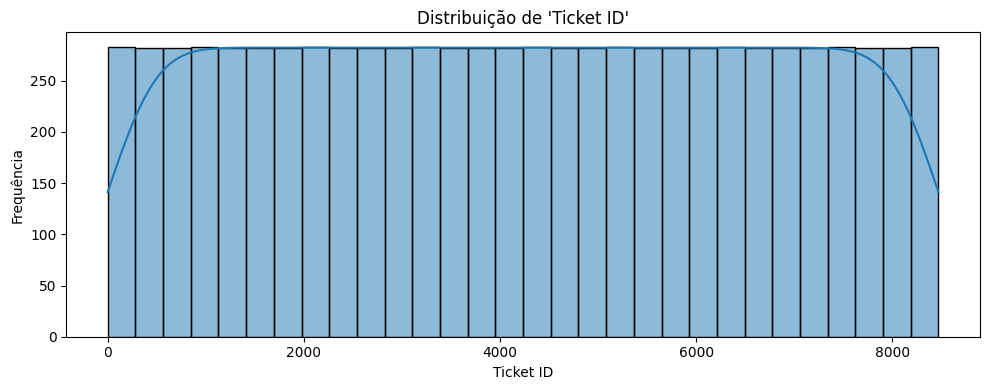


Variável 'Customer Age':
count    8469.000000
mean       44.026804
std        15.296112
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64




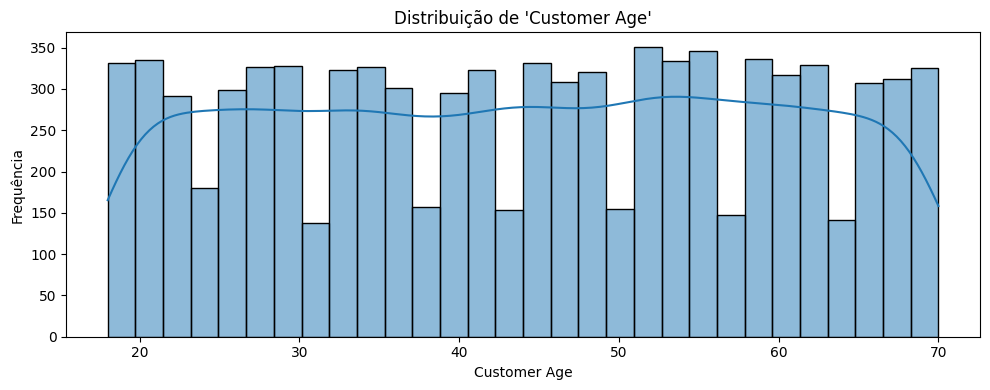


Variável 'Customer Satisfaction Rating':
count    2769.000000
mean        2.991333
std         1.407016
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer Satisfaction Rating, dtype: float64




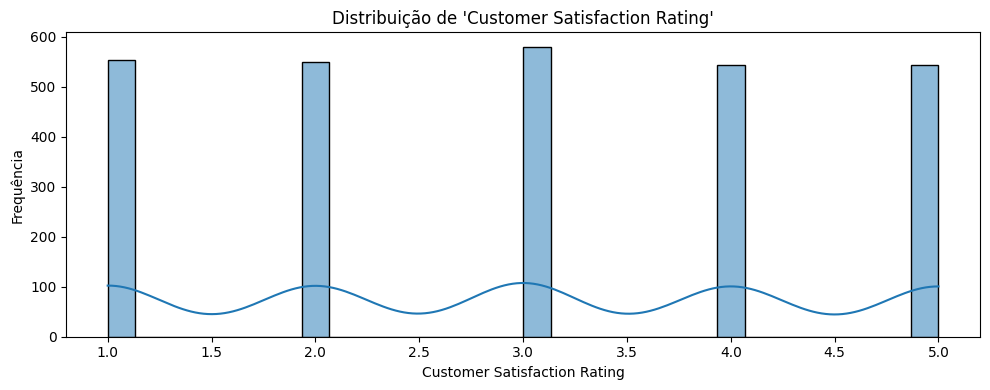

In [119]:
print_formatado("1. Média, mediana, mínimo e máximo:")
for variavel in variaveis_numericas:
    print(f"\nVariável '{variavel}':")
    print(f"Média: {df[variavel].mean():.2f}")
    print(f"Mediana: {df[variavel].median():.2f}")
    print(f"Mínimo: {df[variavel].min()}")
    print(f"Máximo: {df[variavel].max()}")

print_formatado("2. Quartis, variância e desvio-padrão:")
for variavel in variaveis_numericas:
    q1 = df[variavel].quantile(0.25)
    q2 = df[variavel].quantile(0.50)
    q3 = df[variavel].quantile(0.75)
    print(f"\nVariável '{variavel}':")
    print(f"Q1 (25%): {q1:.2f}")
    print(f"Q2 (50% - mediana): {q2:.2f}")
    print(f"Q3 (75%): {q3:.2f}")
    print(f"Variância: {df[variavel].var():.2f}")
    print(f"Desvio-padrão: {df[variavel].std():.2f}")

print_formatado("3. Distribuição dos valores:")
for variavel in variaveis_numericas:
    print(f"\nVariável '{variavel}':")
    print(df[variavel].describe())
    print("\n")
    plt.figure(figsize=(10, 4))
    sns.histplot(df[variavel], kde=True, bins=30)
    plt.title(f"Distribuição de '{variavel}'")
    plt.xlabel(variavel)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()


### **Observações da Análise Univariada - Variáveis Numéricas**

* A variável `Ticket ID` não foi considerada por se tratar de um identificador único.
* Variável `Customer Age`:
  * Possuí média de 44,03 anos e mediana de 44. Valores praticamente identicos.
  * Apresenta 18 anos como o valor mínimo e 70 anos como o valor máximo.
  * Foram observados os quartis, Q1 com valor 31,00, Q3 com valor 57,00 e Amplitude Interquartil (Q3 - Q1) igual à 26,00.
  * Além disso, obtivemos o desvio padrão de 15,30, indicando uma dispersão considerável das idades em torno da média. Existindo uma concentração de idades observadas entre 28,73 e 59,33, embora observemos idades fora dessa faixa de concentração.
  * Variância obtida de 233,97.
  * Foi observado no histograma que há uma distribuição dos valores de forma relativamente homogênea, sem haver concentrações de valores em partes específicas do gráfico.
* Variável `Customer Satisfaction Rating`:
  * Possuí média de 2,99 e mediana de 3. Valores praticamente identicos, tendo as avaliações centradas no ponto médio da escala
  * Apresenta 1 como o valor mínimo e 5 anos como o valor máximo.
  * Foram observados os quartis, Q1 com valor 2, Q3 com valor 4 e Amplitude Interquartil (Q3 - Q1) igual à 2.
  * Variância obtida de 1,98.
  * Além disso, obtivemos o desvio padrão de 1,41, indicando que as avaliações estão espalhadas por toda a escala de notas.
  * Foi observado no histograma que há uma distribuição dos valores de forma homogênea, sem haver concentrações de valores em partes específicas do gráfico.

## **Variáveis Categóricas**

1. Quantidade de categorias:

Quantidade de categorias únicas por variável:
Customer Gender       3
Product Purchased    42
Ticket Type           5
Ticket Subject       16
Ticket Status         3
Ticket Priority       4
Ticket Channel        4
dtype: int64


2. Frequência absoluta e relativa:

Frequência absoluta:

Variável 'Customer Gender':
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64


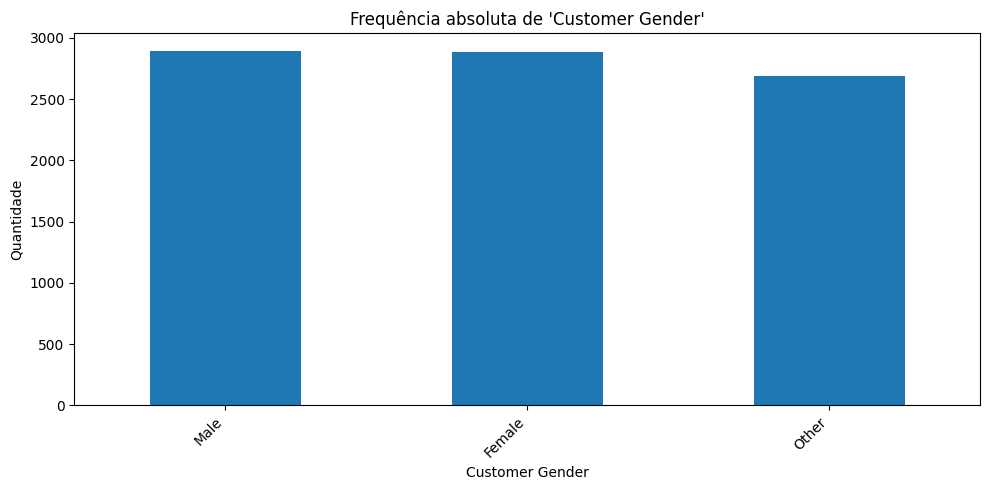


Variável 'Product Purchased':
Product Purchased
Canon EOS                         240
GoPro Hero                        228
Nest Thermostat                   225
Philips Hue Lights                221
Amazon Echo                       221
LG Smart TV                       219
Sony Xperia                       217
Roomba Robot Vacuum               216
Apple AirPods                     213
LG OLED                           213
iPhone                            212
Sony 4K HDR TV                    210
LG Washing Machine                208
Garmin Forerunner                 208
Canon DSLR Camera                 206
Nikon D                           204
Nintendo Switch Pro Controller    203
Google Pixel                      203
Fitbit Charge                     202
Sony PlayStation                  202
HP Pavilion                       200
Microsoft Office                  200
Dyson Vacuum Cleaner              198
Amazon Kindle                     198
Google Nest                       198
B

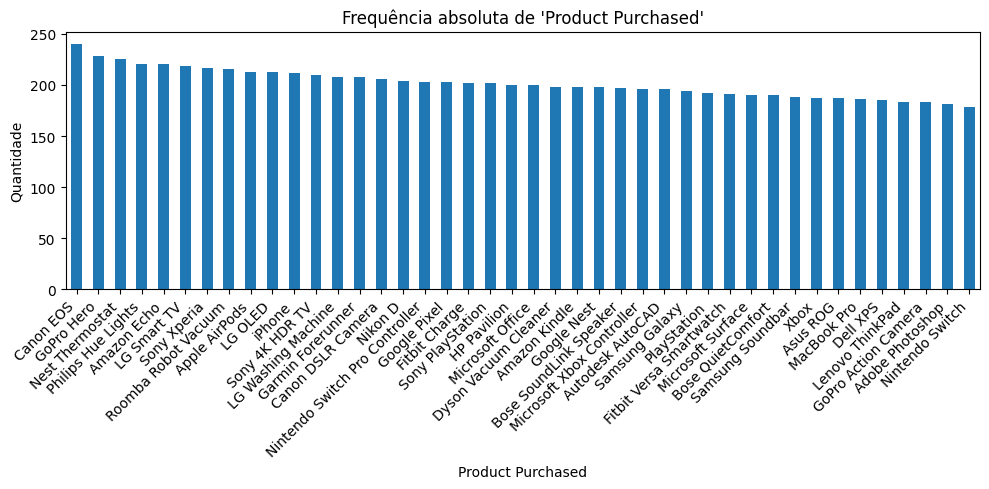


Variável 'Ticket Type':
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


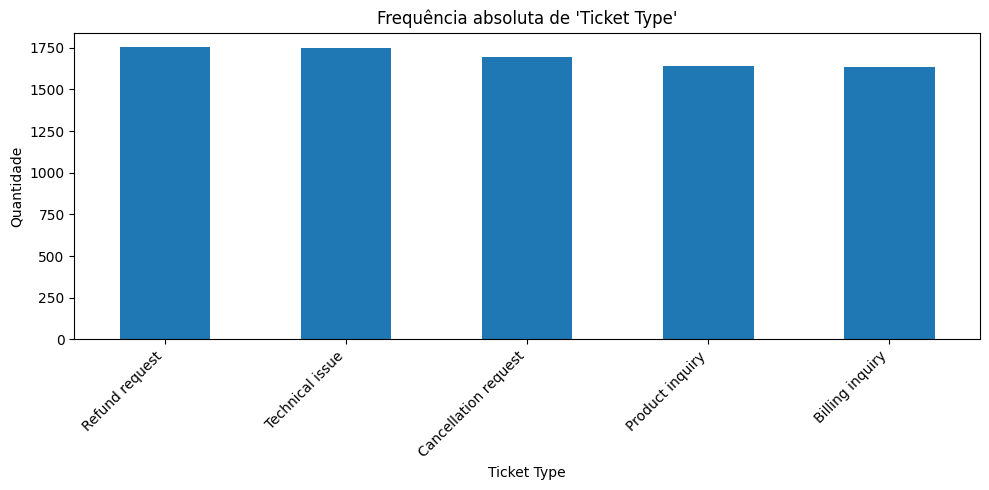


Variável 'Ticket Subject':
Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64


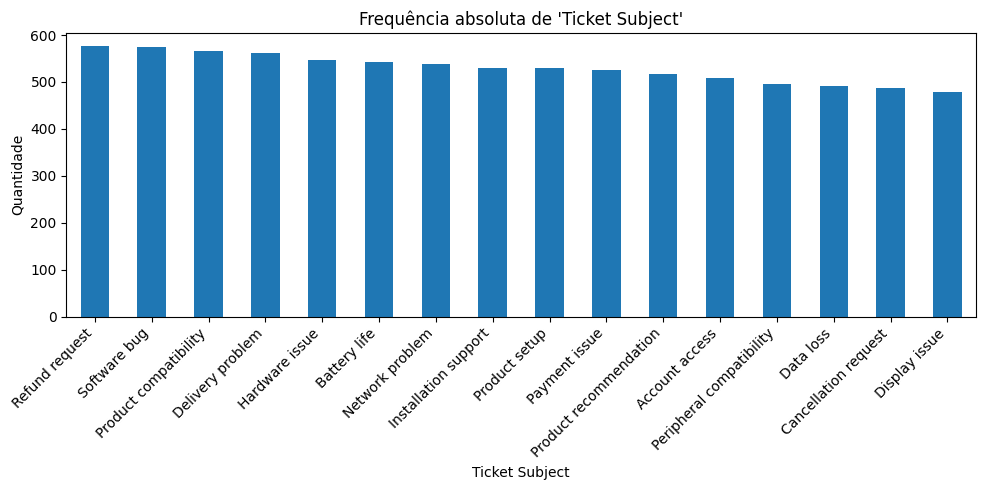


Variável 'Ticket Status':
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64


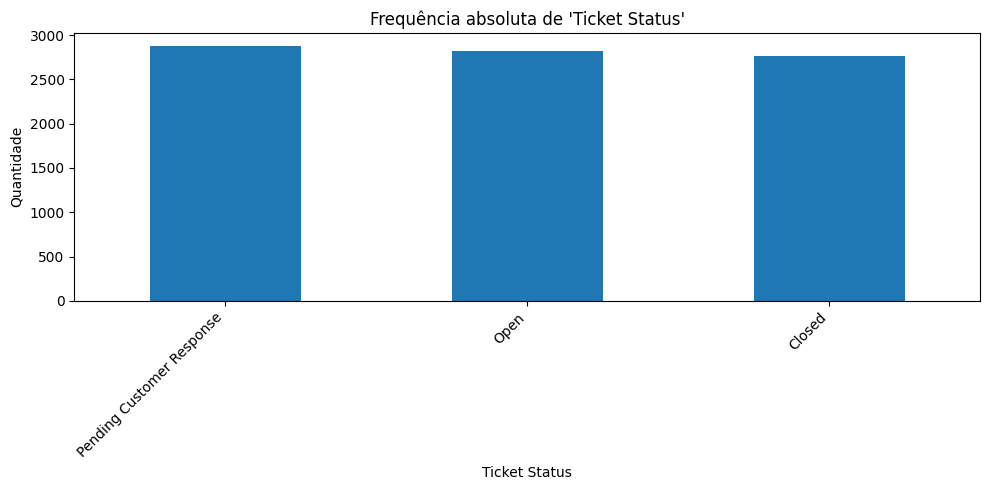


Variável 'Ticket Priority':
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


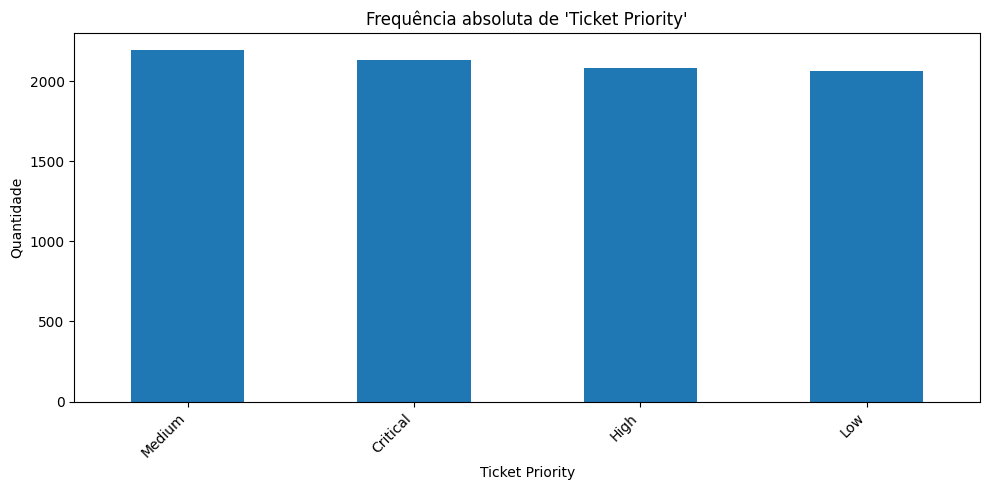


Variável 'Ticket Channel':
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64


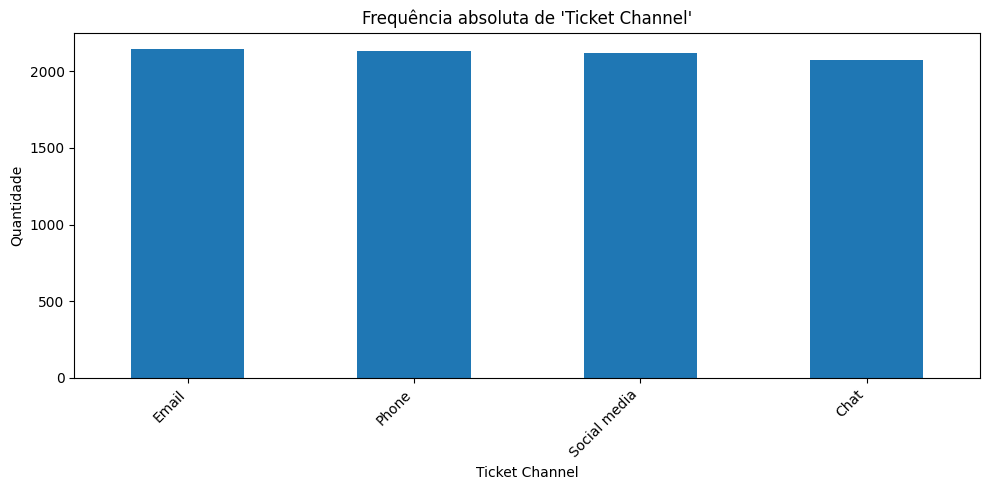


Frequência relativa:

Variável 'Customer Gender' (%):
Customer Gender
Male      0.34
Female    0.34
Other     0.32
Name: proportion, dtype: float64

Variável 'Customer Gender' (%):
Customer Gender
Male      0.34
Female    0.34
Other     0.32
Name: proportion, dtype: float64


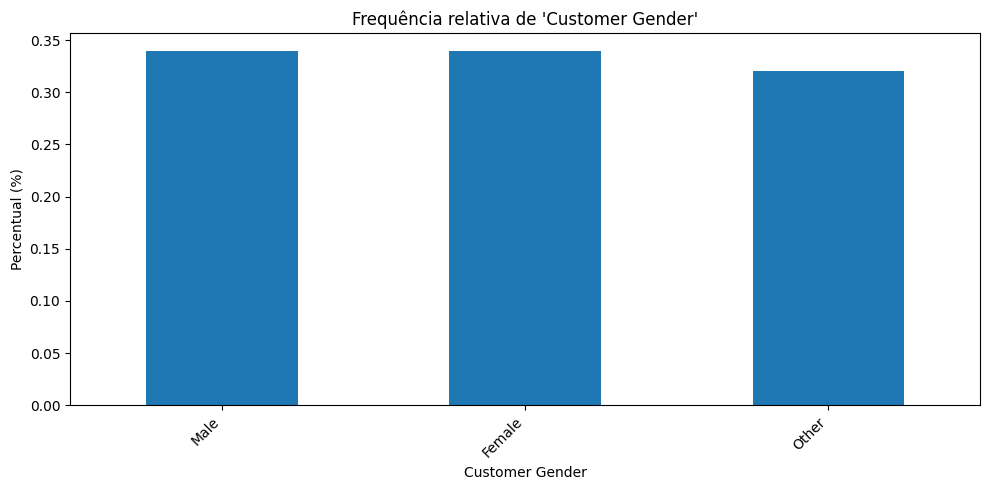


Variável 'Product Purchased' (%):
Product Purchased
Canon EOS                         0.03
GoPro Hero                        0.03
Nest Thermostat                   0.03
Philips Hue Lights                0.03
Amazon Echo                       0.03
LG Smart TV                       0.03
Sony Xperia                       0.03
Roomba Robot Vacuum               0.03
Apple AirPods                     0.03
LG OLED                           0.03
iPhone                            0.03
Sony 4K HDR TV                    0.02
LG Washing Machine                0.02
Garmin Forerunner                 0.02
Canon DSLR Camera                 0.02
Nikon D                           0.02
Nintendo Switch Pro Controller    0.02
Google Pixel                      0.02
Fitbit Charge                     0.02
Sony PlayStation                  0.02
HP Pavilion                       0.02
Microsoft Office                  0.02
Dyson Vacuum Cleaner              0.02
Amazon Kindle                     0.02
Google Nest

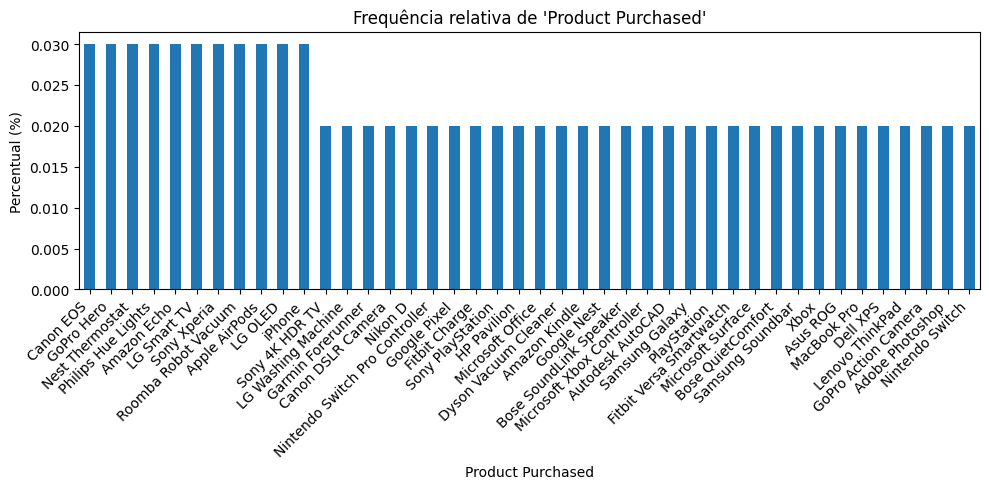


Variável 'Ticket Type' (%):
Ticket Type
Refund request          0.21
Technical issue         0.21
Cancellation request    0.20
Product inquiry         0.19
Billing inquiry         0.19
Name: proportion, dtype: float64

Variável 'Ticket Type' (%):
Ticket Type
Refund request          0.21
Technical issue         0.21
Cancellation request    0.20
Product inquiry         0.19
Billing inquiry         0.19
Name: proportion, dtype: float64


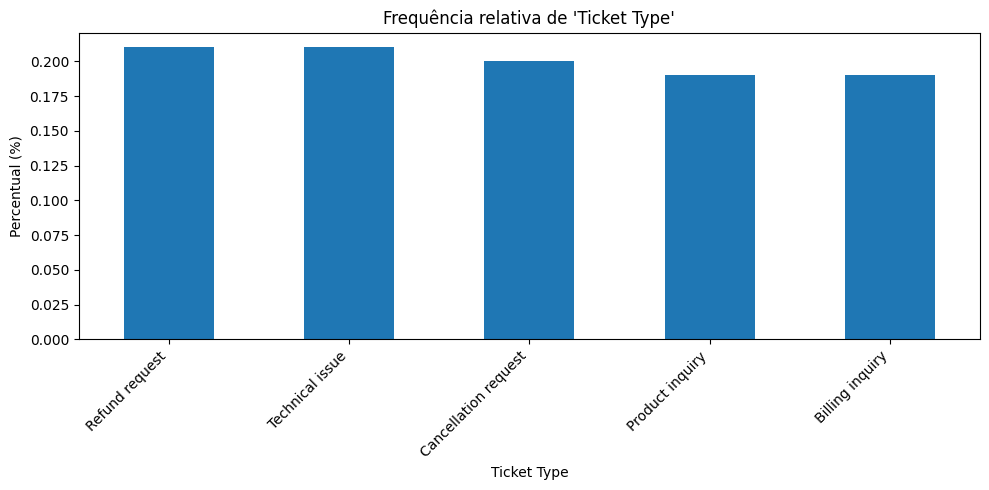


Variável 'Ticket Subject' (%):
Ticket Subject
Refund request              0.07
Software bug                0.07
Product compatibility       0.07
Delivery problem            0.07
Hardware issue              0.06
Battery life                0.06
Network problem             0.06
Installation support        0.06
Product setup               0.06
Payment issue               0.06
Product recommendation      0.06
Account access              0.06
Peripheral compatibility    0.06
Data loss                   0.06
Cancellation request        0.06
Display issue               0.06
Name: proportion, dtype: float64

Variável 'Ticket Subject' (%):
Ticket Subject
Refund request              0.07
Software bug                0.07
Product compatibility       0.07
Delivery problem            0.07
Hardware issue              0.06
Battery life                0.06
Network problem             0.06
Installation support        0.06
Product setup               0.06
Payment issue               0.06
Product recomme

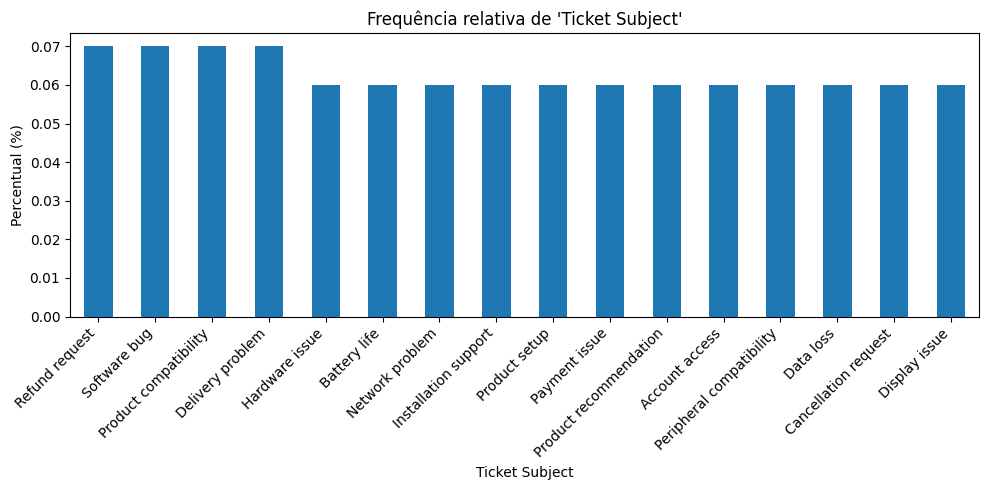


Variável 'Ticket Status' (%):
Ticket Status
Pending Customer Response    0.34
Open                         0.33
Closed                       0.33
Name: proportion, dtype: float64

Variável 'Ticket Status' (%):
Ticket Status
Pending Customer Response    0.34
Open                         0.33
Closed                       0.33
Name: proportion, dtype: float64


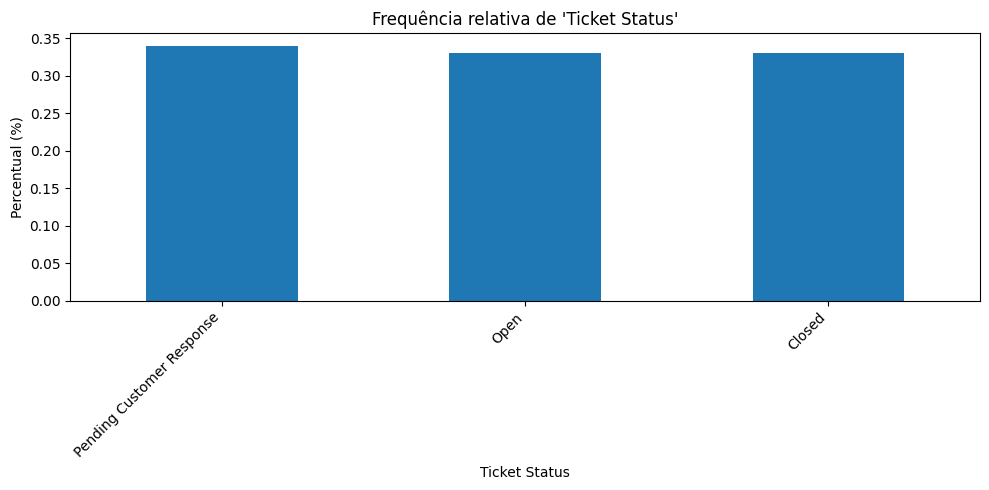


Variável 'Ticket Priority' (%):
Ticket Priority
Medium      0.26
Critical    0.25
High        0.25
Low         0.24
Name: proportion, dtype: float64

Variável 'Ticket Priority' (%):
Ticket Priority
Medium      0.26
Critical    0.25
High        0.25
Low         0.24
Name: proportion, dtype: float64


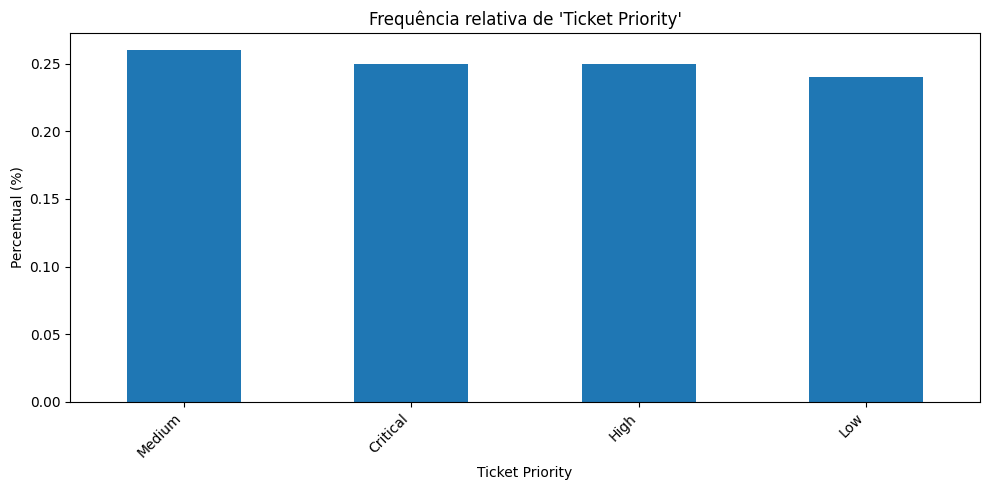


Variável 'Ticket Channel' (%):
Ticket Channel
Email           0.25
Phone           0.25
Social media    0.25
Chat            0.24
Name: proportion, dtype: float64

Variável 'Ticket Channel' (%):
Ticket Channel
Email           0.25
Phone           0.25
Social media    0.25
Chat            0.24
Name: proportion, dtype: float64


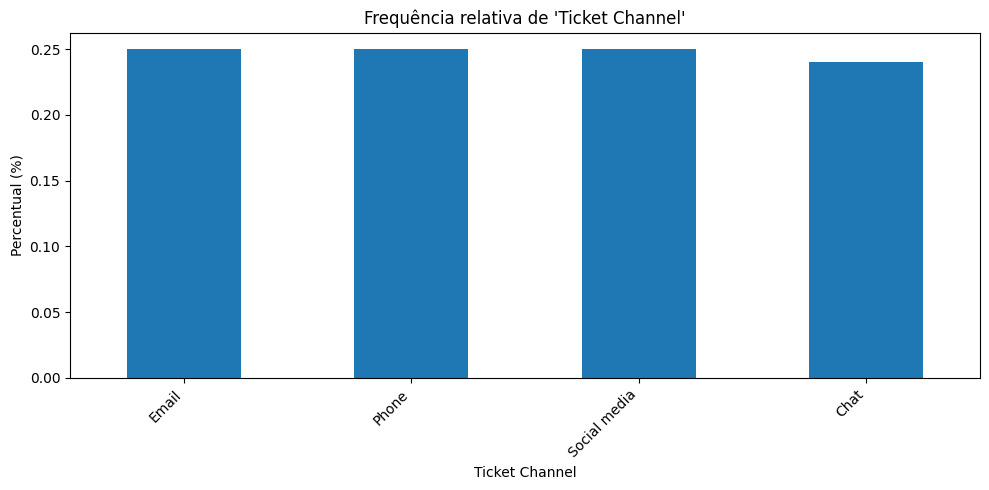



3. Categoria mais frequente:

Categoria mais frequente da variável 'Customer Gender':
Categoria: Male
Quantidade: 2896
Percentual: 34.20%

Categoria mais frequente da variável 'Product Purchased':
Categoria: Canon EOS
Quantidade: 240
Percentual: 2.83%

Categoria mais frequente da variável 'Ticket Type':
Categoria: Refund request
Quantidade: 1752
Percentual: 20.69%

Categoria mais frequente da variável 'Ticket Subject':
Categoria: Refund request
Quantidade: 576
Percentual: 6.80%

Categoria mais frequente da variável 'Ticket Status':
Categoria: Pending Customer Response
Quantidade: 2881
Percentual: 34.02%

Categoria mais frequente da variável 'Ticket Priority':
Categoria: Medium
Quantidade: 2192
Percentual: 25.88%

Categoria mais frequente da variável 'Ticket Channel':
Categoria: Email
Quantidade: 2143
Percentual: 25.30%


In [120]:
print("1. Quantidade de categorias:")
print("\nQuantidade de categorias únicas por variável:")
quantidade_categorias = df[variaveis_categoricas].nunique()
print(quantidade_categorias)

print_formatado("2. Frequência absoluta e relativa:")

print("\nFrequência absoluta:")
for variavel in variaveis_categoricas:
    frequencia_absoluta = df[variavel].value_counts(dropna=False)
    print(f"\nVariável '{variavel}':")
    print(frequencia_absoluta)

    plt.figure(figsize=(10, 5))

    frequencia_absoluta.plot(kind="bar")

    plt.title(f"Frequência absoluta de '{variavel}'")
    plt.xlabel(variavel)
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

print("\nFrequência relativa:")
for variavel in variaveis_categoricas:
    frequencia_relativa = (
        df[variavel]
        .value_counts(normalize=True, dropna=False)
        .round(2)
    )
    print(f"\nVariável '{variavel}' (%):")
    print(frequencia_relativa)

    print(f"\nVariável '{variavel}' (%):")
    print(frequencia_relativa.round(2))

    plt.figure(figsize=(10, 5))
    frequencia_relativa.plot(kind="bar")

    plt.title(f"Frequência relativa de '{variavel}'")
    plt.xlabel(variavel)
    plt.ylabel("Percentual (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

print_formatado("3. Categoria mais frequente:")
for variavel in variaveis_categoricas:
    categoria_mais_frequente = df[variavel].mode(dropna=False)[0]
    quantidade = df[variavel].value_counts(dropna=False).iloc[0]

    percentual = (
        df[variavel]
        .value_counts(normalize=True, dropna=False)
        .iloc[0] * 100
    )

    print(f"\nCategoria mais frequente da variável '{variavel}':")
    print(f"Categoria: {categoria_mais_frequente}")
    print(f"Quantidade: {quantidade}")
    print(f"Percentual: {percentual:.2f}%")

### **Observações da Análise Univariada - Variáveis Categóricas**

* Variável `Customer Gender`:
  * Possui 3 valores categóricos: `Male`, `Female` e `Other`.
  * Os 3 valores possuem frequências absolutas e relativas bastante similares com os valores de 34% (`Male`), 34% (`Female`) e 32% `Other`. Sendo representados por gráficos de frequência absolutas e relativas homogêneos.
  * O valor mais frequênte é a categoria `Male` com 2896 ocorrências (34%).
  * Os gráficos observados são homogêneos, não há nenhuma categoria concentrando as ocorrências.

* Variável `Product Purchased`:
  * Possui 42 valores categóricos, sendo alguns exemplos `Canon EOS`, `GoPro Hero`, `Nest Thermostat`, `Philips Hue Lights` e `Amazon Echo`.
  * As suas categorias apresentam frequências absolutas relativamente próximas, distribuídas entre o valor máximo de 240 para a categoria `Canon EOS` e o valor de 178 para a categoria `Nintendo Switch`. Havendo uma diferença de 62 registros entre as categorias mais e menos recorrentes.
  * As categorias apresentam frequências relativas bem distribuídas, com o valor máximo de 3% e mínimo de 2%.
  * O valor mais frequênte é a categoria `Canon EOS` com 240 ocorrências (3%).
  * O gráfico observado de frequência relativa é homogêneo, não existindo nenhuma categoria concentrando as ocorrências, porém no gráfico de frequência absoluta é possivel observar um certo desnível entre as categorias, embora os valores ainda sejam relativamente próximos.

* Variável `Ticket Type`:
  * Possui 5 valores categóricos: `Refund request`, `Technical issue`, `Cancellation request`, `Product inquiry` e `Billing inquiry`.
  * As suas categorias apresentam frequências absolutas relativamente próximas, distribuídas entre o valor máximo de 1752 para a categoria `Refund request` e o valor de 1634 para a categoria `Billing inquiry`. Havendo uma diferença de 118 registros entre as categorias mais e menos recorrentes.
  * As categorias apresentam frequências relativas bem distribuídas, com o valor máximo de 21% e mínimo de 18%.
  * O valor mais frequênte é a categoria `Refund request` com 1752 ocorrências (21%).
  * O gráfico observado de frequência relativa é homogêneo, não existindo nenhuma categoria concentrando as ocorrências, porém no gráfico de frequência absoluta é possivel observar um certo desnível entre as categorias, embora os valores ainda sejam relativamente próximos.

* Variável `Ticket Subject`:
  * Variável Alvo.
  * Possui 16 valores categóricos: `Refund request`, `Software bug`, `Product compatibility`, `Delivery problem` e `Hardware issue`.
  * As suas categorias apresentam frequências absolutas relativamente próximas, distribuídas entre o valor máximo de 576 para a categoria `Refund request` e o valor de 478 para a categoria `Display issue`. Havendo uma diferença de 98 registros entre as categorias mais e menos recorrentes.
  * As categorias apresentam frequências relativas bem distribuídas, com o valor máximo de 7% e mínimo de 6%.
  * O valor mais frequênte é a categoria `Refund request` com 576 ocorrências (7%).
  * O gráfico observado de frequência relativa é homogêneo, não existindo nenhuma categoria concentrando as ocorrências, porém no gráfico de frequência absoluta é possivel observar um certo desnível entre as categorias, embora os valores ainda sejam relativamente próximos.

* Variável `Ticket Status`:
  * Possui 3 valores categóricos: `Pending Customer Response`, `Open` e `Closed`.
  * As suas categorias apresentam frequências absolutas relativamente próximas, distribuídas entre o valor máximo de 2881 para a categoria `Pending Customer Response` e o valor de 2769 para a categoria `Closed`. Havendo uma diferença de 112 registros entre as categorias mais e menos recorrentes.
  * As categorias apresentam frequências relativas bem distribuídas, com o valor máximo de 34% e mínimo de 33%.
  * O valor mais frequênte é a categoria `Pending Customer Response` com 2881 ocorrências (34%).
  * O gráfico observado de frequência relativa é homogêneo, não existindo nenhuma categoria concentrando as ocorrências, porém no gráfico de frequência absoluta é possivel observar um certo desnível entre as categorias, embora os valores ainda sejam relativamente próximos.

* Variável `Ticket Priority`:
  * Possui 4 valores categóricos: `Medium`, `Critical`, `High` e `Low`.
  * As suas categorias apresentam frequências absolutas relativamente próximas, distribuídas entre o valor máximo de 2192 para a categoria `Medium` e o valor de 2063 para a categoria `Low`. Havendo uma diferença de 129 registros entre as categorias mais e menos recorrentes.
  * As categorias apresentam frequências relativas bem distribuídas, com o valor máximo de 26% e mínimo de 24%.
  * O valor mais frequênte é a categoria `Medium` com 2192 ocorrências (26%).
  * Em ambos os gráficos de frequência absoluta e relativa é possivel observar um certo desnível entre as categorias, embora os valores ainda sejam relativamente próximos.


* Variável `Ticket Channel`:
  * Possui 4 valores categóricos: `Email`, `Phone`, `Social media` e `Chat`.
  * As suas categorias apresentam frequências absolutas relativamente próximas, distribuídas entre o valor máximo de 2143 para a categoria `Email` e o valor de 2073 para a categoria `Chat`. Havendo uma diferença de 70 registros entre as categorias mais e menos recorrentes.
  * As categorias apresentam frequências relativas bem distribuídas, com o valor máximo de 25% e mínimo de 24%.
  * O valor mais frequênte é a categoria `Email` com 2143 ocorrências (25%).
  * Em ambos os gráficos de frequência absoluta e relativa é possivel observar um certo desnível entre as categorias, embora os valores ainda sejam relativamente próximos.

## **Variáveis Textuais**



Análise da Variável Textual: Ticket Description
1. Estatísticas tamanho do texto e quantidade palavras:

Tamanho do texto (Ticket Description):
count        8469.0
mean     273.665604
std       43.834932
min           143.0
25%           254.0
50%           283.0
75%           303.0
max           384.0
Name: Ticket Description_tamanho, dtype: Float64

Quantidade de palavras (Ticket Description):
count       8469.0
mean     46.117487
std       8.621661
min           21.0
25%           42.0
50%           48.0
75%           52.0
max           63.0
Name: Ticket Description_qtd_palavras, dtype: Float64


2. Distribuição tamanho do texto e quantidade de palavras (Ticket Description)


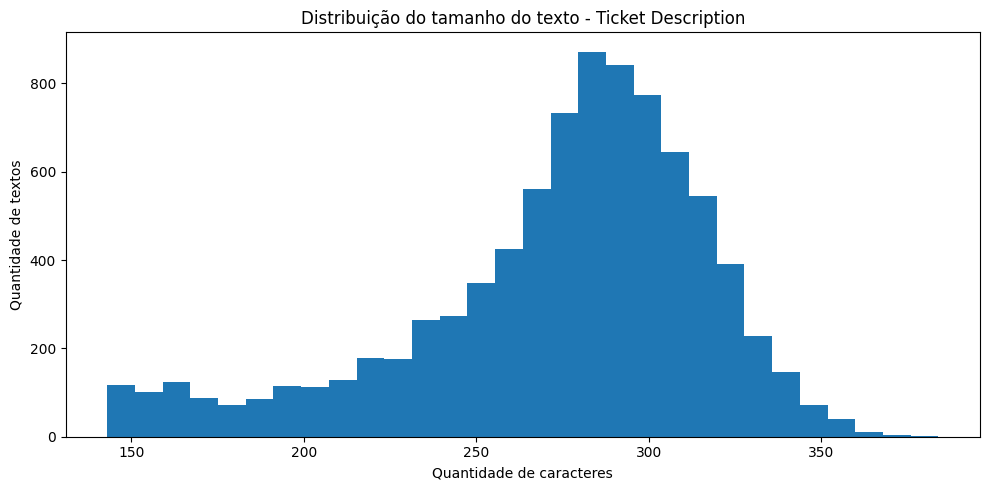

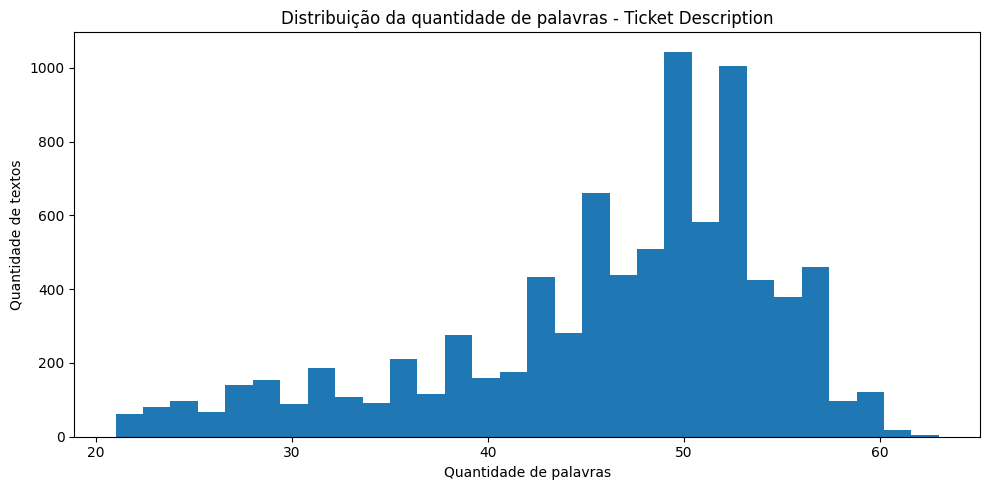



3. Palavras mais frequentes (Ticket Description)
Top 20 palavras em 'Ticket Description':

                palavra  frequencia
5829  product_purchased       14033
4282              issue       11528
4069                 im       10287
3639             having        6430
1550             assist        6250
4321                ive        6001
5713            problem        2285
5730            product        2226
2542               data        1654
6856           software        1552
1239            account        1460
7001              steps        1390
5125            noticed        1208
5459           persists        1178
3660               help        1176
6359            resolve        1165
7585             update        1155
2688             device        1106
7522             unable        1088
7445              tried        1034


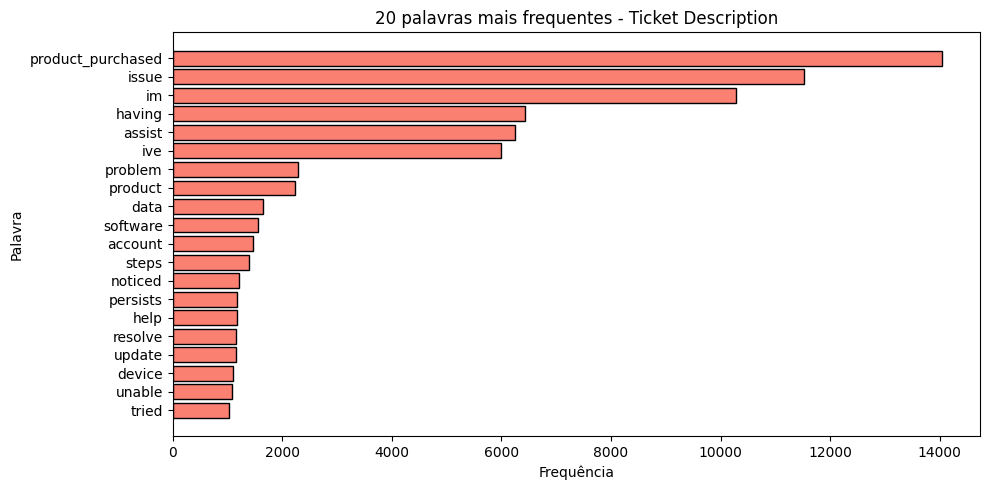



Análise da Variável Textual: Resolution
1. Estatísticas tamanho do texto e quantidade palavras:

Tamanho do texto (Resolution):
count       2769.0
mean     34.798122
std      10.739092
min           10.0
25%           26.0
50%           34.0
75%           43.0
max           68.0
Name: Resolution_tamanho, dtype: Float64

Quantidade de palavras (Resolution):
count      2769.0
mean     5.486818
std      1.475446
min           3.0
25%           4.0
50%           5.0
75%           7.0
max           8.0
Name: Resolution_qtd_palavras, dtype: Float64


2. Distribuição tamanho do texto e quantidade de palavras (Resolution)


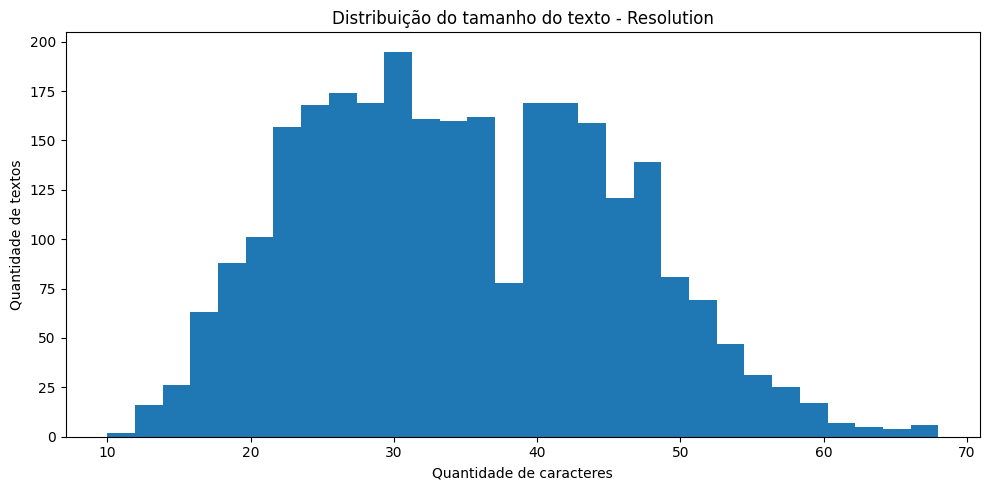

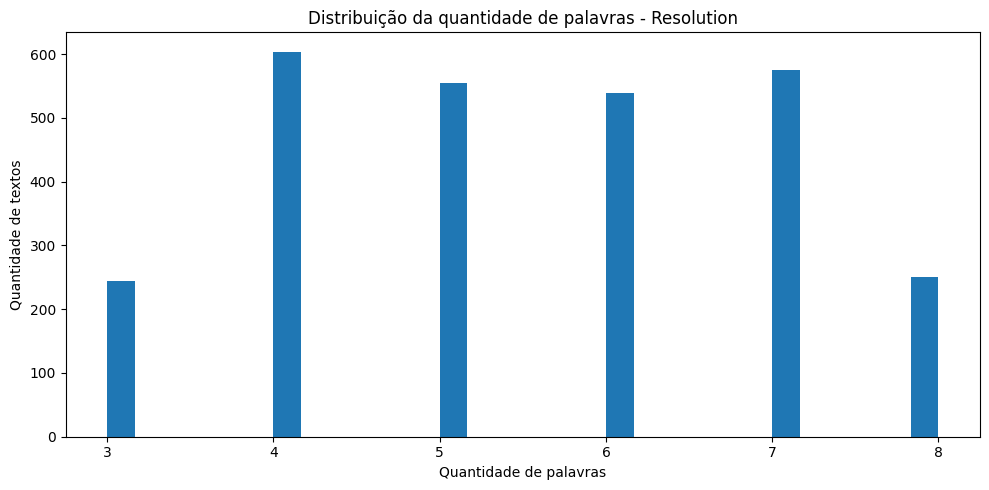



3. Palavras mais frequentes (Resolution)
Top 20 palavras em 'Resolution':

       palavra  frequencia
216   evidence          30
480      piece          29
356        leg          25
67         bit          25
696       time          25
532       rate          25
60    behavior          25
66     billion          25
46   available          25
128     common          25
203   employee          24
85      camera          24
221     expect          24
403     middle          24
182    discuss          24
131    compare          24
561    respond          24
155        cut          24
185        dog          23
297        hit          23


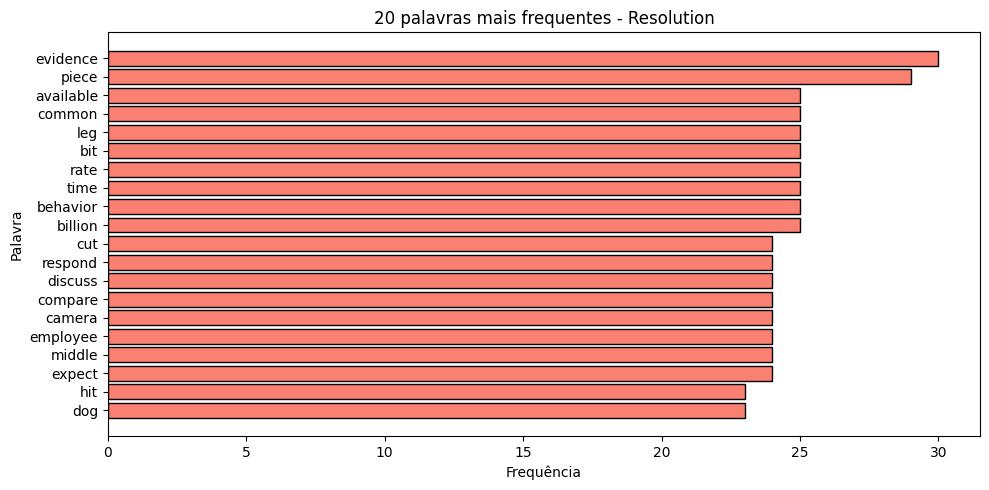

In [121]:
for variavel in variaveis_textuais_com_tratamento:
    print_formatado(f"Análise da Variável Textual: {variavel}")

    col_tamanho = f"{variavel}_tamanho"
    col_qtd_palavras = f"{variavel}_qtd_palavras"

    print("1. Estatísticas tamanho do texto e quantidade palavras:")

    print(f"\nTamanho do texto ({variavel}):")
    print(df[col_tamanho].describe())

    print(f"\nQuantidade de palavras ({variavel}):")
    print(df[col_qtd_palavras].describe())

    print_formatado(f"2. Distribuição tamanho do texto e quantidade de palavras ({variavel})")

    plt.figure(figsize=(10, 5))
    plt.hist(df[col_tamanho].dropna(), bins=30)
    plt.title(f"Distribuição do tamanho do texto - {variavel}")
    plt.xlabel("Quantidade de caracteres")
    plt.ylabel("Quantidade de textos")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.hist(df[col_qtd_palavras].dropna(), bins=30)
    plt.title(f"Distribuição da quantidade de palavras - {variavel}")
    plt.xlabel("Quantidade de palavras")
    plt.ylabel("Quantidade de textos")
    plt.tight_layout()
    plt.show()

    print_formatado(f"3. Palavras mais frequentes ({variavel})")

    X_vet = matrizes_vetorizadas[variavel]
    vocab = vocabularios[variavel]

    frequencia_palavras = X_vet.sum(axis=0).A1

    df_frequencia_palavras = pd.DataFrame({
        "palavra": vocab,
        "frequencia": frequencia_palavras
    })

    df_frequencia_palavras = (
        df_frequencia_palavras
        .sort_values("frequencia", ascending=False)
        .head(20)
    )

    print(f"Top 20 palavras em '{variavel}':\n")
    print(df_frequencia_palavras)

    plt.figure(figsize=(10, 5))
    dados_plot = df_frequencia_palavras.sort_values("frequencia")

    plt.barh(
        dados_plot["palavra"],
        dados_plot["frequencia"],
        color='salmon',
        edgecolor='black'
    )

    plt.title(f"20 palavras mais frequentes - {variavel}")
    plt.xlabel("Frequência")
    plt.ylabel("Palavra")
    plt.tight_layout()
    plt.show()

### **Observações da Análise Univariada - Variáveis Textuais**

**Observação:** Das variáveis textuais só analisamos os valores das variáveis `Ticket Description` e `Resolution`. Pois as variáveis `Customer Name`, `Customer Email` se referem apenas a dados de identificação do cliente, não tendo relação deterministica com o `Ticket Subject`.

* Variável `Ticket Description`:

  * Tamanho do Texto:
    * Possuí em média 273,66 caracteres, com mediana de 283 caracteres. Valores relativamente diferentes.
    * Possuí tamanho mínimo de 143 caracteres e máximo de 384 caracteres.
    * Foram observados os quartis, Q1 com valor 254, Q3 com valor 303 e Amplitude Interquartil (Q3 - Q1) igual à 49.
    * Além disso, obtivemos o desvio padrão de 43,83, indicando uma dispersão considerável da quantidade de caracteres em torno da média. Existindo uma concentração de valores observados entre 229,83 e 317,49, embora observemos valores fora dessa faixa de concentração.
    * Observando o gráfico de distribuição do tamanho do texto, percebemos uma distribuição assimétrica à esquerda, com cauda a esquerda. Indicando uma concentração dos maiores valores de quantidade de caracteres.

  * Quantidade de Palavras:
    * Possuí em média 46,11 palavras, com mediana de 48 palavras. Valores próximos.
    * Possuí tamanho mínimo de 21 palavras e máximo de 63 palavras.
    * Foram observados os quartis, Q1 com valor 42, Q3 com valor 52 e Amplitude Interquartil (Q3 - Q1) igual à 10.
    * Além disso, obtivemos o desvio padrão de 8,62, indicando uma dispersão pequena da quantidade de palavras em torno da média. Existindo uma concentração de valores observados entre 37,49 e 54,73, embora observemos valores fora dessa faixa de concentração.
    * Observando o gráfico de distribuição de quantidade de palavras, percebemos uma distribuição assimétrica à esquerda, com cauda a esquerda. Indicando uma concentração dos maiores valores de quantidade de caracteres.

* Variável `Resolution`:

  * Tamanho do Texto:
    * Possuí em média 34,7981 caracteres, com mediana de 34 caracteres. Valores próximos.
    * Possuí tamanho mínimo de 10 caracteres e máximo de 68 caracteres.
    * Foram observados os quartis, Q1 com valor 26,00, Q3 com valor 43,00 e Amplitude Interquartil (Q3 - Q1) igual à 17,00.
    * Além disso, obtivemos o desvio padrão de 10,73, indicando uma dispersão considerável da quantidade de caracteres em torno da média. Existindo uma concentração de valores observados entre 24,0681 e 45,5281, embora observemos valores fora dessa faixa de concentração.
    * Observando o gráfico de distribuição do tamanho do texto, percebemos um formato similar a um sino, indicando uma distribuição normal, porém ainda é necessário uma análise mais aprofundada dessa distribuição.

  * Quantidade de Palavras:
    * Possuí em média 5,48 palavras, com mediana de 5 palavras. Valores próximos.
    * Possuí tamanho mínimo de 3 palavras e máximo de 8 palavras.
    * Foram observados os quartis, Q1 com valor 4,00, Q3 com valor 7,00 e Amplitude Interquartil (Q3 - Q1) igual à 3,00.
    * Além disso, obtivemos o desvio padrão de 1.47, indicando uma dispersão pequena da quantidade de palavras em torno da média. Existindo uma concentração de valores observados entre 4,01 e 6,97, embora observemos valores fora dessa faixa de concentração.
    * Observando o gráfico de distribuição de quantidade de palavras, percebemos um formato similar a um sino, indicando uma distribuição normal, porém ainda é necessário uma análise mais aprofundada dessa distribuição.


# **Análise Multivariada**

## **Variáveis Numéricas**



1. Relação entre variáveis numéricas x alvo categórico:

-----Customer Age x Ticket Subject-----:

Customer Age
ANOVA: F = 0.353, p = 0.9894
                            N  Média  Mediana  Desvio_Padrão  Minimo  Máximo  \
Ticket Subject                                                                 
Account access            509  43.81     44.0          15.83      18      70   
Battery life              542  43.61     44.0          14.82      18      70   
Cancellation request      487  44.54     44.0          15.31      18      70   
Data loss                 491  43.73     43.0          15.19      18      70   
Delivery problem          561  44.61     45.0          15.31      18      70   
Display issue             478  43.34     44.0          15.36      18      70   
Hardware issue            547  43.90     44.0          15.29      18      70   
Installation support      530  44.72     46.0          15.48      18      70   
Network problem           539  44.27     45.0          15

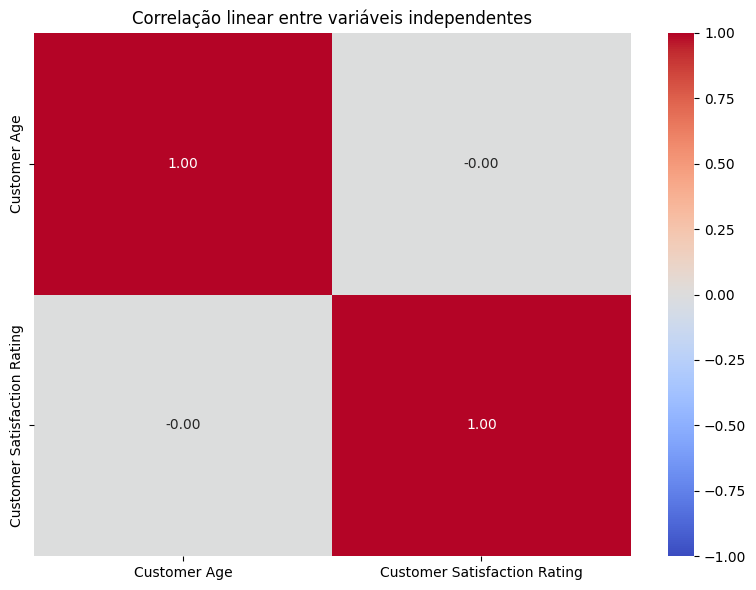


Pares ordenados pela maior correlação absoluta:
Customer Age x Customer Satisfaction Rating: r = -0.004 (negativa)


3. Correlação não-linear entre variáveis independentes:

Matriz de correlação de Spearman:
                              Customer Age  Customer Satisfaction Rating
Customer Age                         1.000                        -0.004
Customer Satisfaction Rating        -0.004                         1.000

Heatmat:


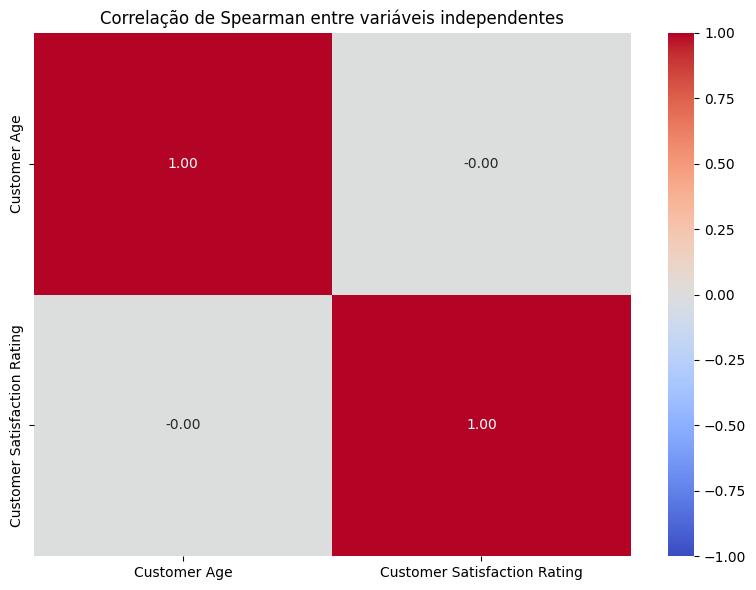


Pares ordenados pela maior correlação absoluta:
Customer Age x Customer Satisfaction Rating: ρ = -0.004 (negativa)


In [122]:
print_formatado("1. Relação entre variáveis numéricas x alvo categórico:")

variaveis_numericas_relevantes = ['Customer Age', 'Customer Satisfaction Rating']
for variavel in variaveis_numericas_relevantes:

    print(f"\n-----{variavel} x {variavel_alvo}-----:")

    grupos = [
        grupo[variavel].dropna()
        for _, grupo in df.groupby(variavel_alvo, observed=True)
    ]

    estatistica, p_valor = stats.f_oneway(*grupos)

    print(f"\n{variavel}")
    print(f"ANOVA: F = {estatistica:.3f}, p = {p_valor:.4f}")

    estatisticas = (
        df.groupby(variavel_alvo, observed=True)[variavel]
        .agg(
            N="count",
            Média="mean",
            Mediana="median",
            Desvio_Padrão="std",
            Minimo="min",
            Máximo="max",
            Q1=lambda x: x.quantile(0.25),
            Q3=lambda x: x.quantile(0.75)
        )
        .round(2)
    )

    print(estatisticas)


print_formatado("2. Correlação linear entre variáveis independentes:")
matriz_corr_independentes = df[variaveis_numericas_relevantes].corr(method="pearson")

pares_corr = []
for var1, var2 in combinations(variaveis_numericas_relevantes, 2):
    pares_corr.append((var1, var2, matriz_corr_independentes.loc[var1, var2]))
pares_corr = sorted(pares_corr, key=lambda x: abs(x[2]), reverse=True)

print("\nMatriz de correlação variáveis independentes:")
print(matriz_corr_independentes.round(3))

print("\nHeatmap:")
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr_independentes, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Correlação linear entre variáveis independentes")
plt.tight_layout()
plt.show()

print("\nPares ordenados pela maior correlação absoluta:")
for var1, var2, valor in pares_corr:
    sinal = "positiva" if valor > 0 else ("negativa" if valor < 0 else "nula")
    print(f"{var1} x {var2}: r = {valor:.3f} ({sinal})")


print_formatado("3. Correlação não-linear entre variáveis independentes:")

print("\nMatriz de correlação de Spearman:")
matriz_spearman_independentes = df[variaveis_numericas_relevantes].corr(method="spearman")
print(matriz_spearman_independentes.round(3))

print("\nHeatmat:")
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_spearman_independentes, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Correlação de Spearman entre variáveis independentes")
plt.tight_layout()
plt.show()

print("\nPares ordenados pela maior correlação absoluta:")
pares_spearman = []
for var1, var2 in combinations(variaveis_numericas_relevantes, 2):
    pares_spearman.append((var1, var2, matriz_spearman_independentes.loc[var1, var2]))
pares_spearman = sorted(pares_spearman, key=lambda x: abs(x[2]), reverse=True)
for var1, var2, valor in pares_spearman:
    sinal = "positiva" if valor > 0 else ("negativa" if valor < 0 else "nula")
    print(f"{var1} x {var2}: ρ = {valor:.3f} ({sinal})")

### **Observações da Análise Multivariada - Variáveis Numéricas**

**Observação:** A variável `Ticket ID` não foi considerada por se tratar de um identificador único.

### 1. Relação entre variáveis numéricas x alvo categórico

* Como a variável alvo `Ticket Subject` é do tipo `categorica nominal` não é possível utilizar os métodos de correlação de Pearson e Spearman com as variáveis numéricas.

* Então para realizar a análise, os valores das váriaveis numéricas foram agrupados para cada categoria da variável alvo, e para cada grupo foram calculadas estatísticas descritivas das variáveis numéricas, como valores mínimos, máximos, média, mediana, desvio padrão e quartis.

* Essa abordagem descritiva permite observar o comportamento das variáveis numéricas para cada categoria da variável alvo.

* As variáveis `Customer Satisfaction Rating`  e `Customer Age` apresentaram valores de média, mediana, mínimo, máximo e quartis com valores bem próximos entre os grupos de `Ticket Subject`.

* Além disso foi realizado o teste ANOVA para verificar estatisticamente se existe diferença entre os grupos.

* Todas as variáveis numéricas apresentaram p-valor ≥ 0,05 para o teste ANOVA. Portanto, considerando um nível de significância de 5%, não foram encontradas evidências estatísticas suficiente para rejeitar a hipótese nula de que não existe diferença real entre os grupos.

### 2. Correlação linear entre variáveis independentes

* As correlações entre as variáveis numéricas independentes foram muito fracas, com valores próximos de zero.

* A única correlação  observada foi entre `Customer Age` e `Customer Satisfaction Rating`, com `r = -0.004`, indicando uma relação linear negativa muito fraca.

* Não há justificativa para remover variáveis numéricas com base apenas nessa matriz de correlação.

### 3. Correlação não linear entre variáveis independentes

* As correlações de Spearman entre as variáveis numéricas independentes foram muito fracas, com valores próximos de zero.

* A única correlação  observada foi entre `Customer Age` e `Customer Satisfaction Rating`, com `r = -0.004`, indicando uma relação linear negativa muito fraca.

* Não há justificativa para remover variáveis numéricas com base apenas nessa matriz de correlação de Spearman.

* Correlações de Spearman próximas de zero indicam ausência de relação monotônica relevante, mas não descartam relações não monotônicas, como padrões em formato de U.

### 4. Analisar variáveis preditoras

* Como a variável alvo `Ticket Subject` é do tipo `categorica nominal` não é possível utilizar os métodos de correlação de Pearson e Spearman com as variáveis numéricas para assim determinar possíveis variáveis preditoras com esses métodos.

* Foi observado que todas as variáveis numéricas apresentaram p-valor ≥ 0,05 para o teste ANOVA. Portanto, considerando um nível de significância de 5%, não foram encontradas evidências estatísticas suficiente para rejeitar a hipótese nula de que não existe diferença real entre os grupos. Dessa forma, não foram identificadas variáveis numéricas com evidência de associação estatisticamente significativa com a variável alvo e, portanto, nenhuma foi identificada como uma potencial variável preditora.

### 5. Analisar e tratar variáveis redundantes

* Como todas as correlações lineares e não-lineares entre as variáveis independentes apresentaram valores próximos a zero, ou seja, são correlações muito fracas. Não foram encontradas evidências estatísticas de correlação significativas entre as variáveis independentes utilizando os métodos de Pearson e Spearman.

* Portanto, com base exclusivamente nos testes de Pearson e Spearman realizados, não foi identificado nenhum par de variáveis independentes que apresente correlação significativa que justifique serem considerados como redundantes a partir dessa análise.

## **Variáveis Categóricas**

In [123]:
print_formatado("1. Associação entre alvo x independentes:")
for variavel in variaveis_categoricas:
    print(f"\n-----{variavel} x {variavel_alvo}-----:")

    print("\nTabela de contingência:")
    tabela_contingencia = pd.crosstab(df[variavel], df[variavel_alvo])
    print(tabela_contingencia)

    print("\nTeste Qui-quadrado:")
    chi2_value, p_valor, graus_liberdade, frequencias_esperadas = stats.chi2_contingency(tabela_contingencia)
    print(f"χ² = {chi2_value:.3f}")
    print(f"P-valor = {p_valor:.5f}")
    print(f"Graus de liberdade = {graus_liberdade}")

    print("\nV de Cramér:")
    n = tabela_contingencia.to_numpy().sum()
    menor_dimensao = min(tabela_contingencia.shape[0] - 1, tabela_contingencia.shape[1] - 1)
    v_cramer = np.sqrt(chi2_value / (n * menor_dimensao)) if menor_dimensao > 0 else np.nan
    print(f"V de Cramér = {v_cramer:.3f}")

print_formatado("2. Associação entre variáveis independentes:")
for variavel_1, variavel_2 in combinations(variaveis_categoricas, 2):

    if variavel_1 == variavel_alvo or variavel_2 == variavel_alvo:
      continue

    print(f"\n-----{variavel_1} x {variavel_2}-----:")

    print("\nTabela de contingência:")
    tabela_contingencia = pd.crosstab(df[variavel_1], df[variavel_2])
    #print(tabela_contingencia)

    print("\nTeste Qui-quadrado:")
    chi2_value, p_valor, graus_liberdade, frequencias_esperadas = stats.chi2_contingency(tabela_contingencia)
    print(f"χ² = {chi2_value:.3f}")
    print(f"P-valor = {p_valor:.5f}")
    print(f"Graus de liberdade = {graus_liberdade}")

    print("\nV de Cramér:")
    n = tabela_contingencia.to_numpy().sum()
    menor_dimensao = min(tabela_contingencia.shape[0] - 1, tabela_contingencia.shape[1] - 1)
    v_cramer = np.sqrt(chi2_value / (n * menor_dimensao)) if menor_dimensao > 0 else np.nan
    print(f"V de Cramér = {v_cramer:.3f}")



1. Associação entre alvo x independentes:

-----Customer Gender x Ticket Subject-----:

Tabela de contingência:
Ticket Subject   Account access  Battery life  Cancellation request  \
Customer Gender                                                       
Female                      182           173                   164   
Male                        174           187                   164   
Other                       153           182                   159   

Ticket Subject   Data loss  Delivery problem  Display issue  Hardware issue  \
Customer Gender                                                               
Female                 181               206            162             175   
Male                   163               190            147             186   
Other                  147               165            169             186   

Ticket Subject   Installation support  Network problem  Payment issue  \
Customer Gender                                              

### **Observações da Análise de Associação entre Variáveis Categóricas**

### 1. Associação entre alvo x variáveis independentes

* Com exceção da variável alvo `Ticket Subject`, o resto das variáveis apresentaram p-valor ≥ 0.05 no teste de Qui-Quadrado. Portanto, considerando um nível de significância de 5%, não foram encontradas evidências estatísticas suficiente para rejeitar a hipótese nula de que não existe associação significativa entre as variáveis independentes e a variável alvo.

* Com exceção da comparação da variável alvo `Ticket Subject`com ela mesma, todas as variáveis apresentaram V de Cramér abaixo de 0.1, indicando associação muito baixa com a variável alvo.

* A variável `Ticket Type` apresentou o menor valor de V de Cramér (0,034) indicando uma associação muito fraca com a variável alvo `Ticket Subject`. Esse dado pode ser considerado inexperado do ponto de vista analítico, visto que era esperado que o tipo do chamado tivesse uma relação mais evidente com seu assunto.

* Analisando os dados percebemos que há uma distribuição estranhamente artificial entre `Ticket Type` e `Ticket Subject`, o que nos leva a considerar a hipótese de que os dados foram criados ou selecionados artificialmente de modo a deixar a distribuição uniforme.

* Em ordem decrescente de associação segundo o V de Cramér, as variáveis foram: Product purchased (0,070), Ticket Status (0,047), Ticket Priority (0,040), Ticket Channel (0,039), Customer gender (0,038) e Ticket Type (0,034).

* Uma associação fraca não significa necessariamente que a variável seja irrelevante, pois ela pode contribuir por meio de interações com outras variáveis.

* A existência de associação estatística entre duas variáveis não implica relação de causa e efeito.Os testes feitos de Qui-Quadradado e V de Cramér avaliam associação, e não causalidade.

## **Observações da Análise de Associação entre Variáveis Categóricas**

### 2. Associação entre variáveis independentes

* Todas as associações entre variáveis independentes apresentaram p-valor ≥ 0.05 no teste de Qui-Quadrado. Portanto, considerando um nível de significância de 5%, não foram encontradas evidências estatísticas suficiente para rejeitar a hipótese nula de que não existe associação significativa entre as variáveis independentes.

* Todas as associações entre as variáveis independentes possui valor V de Cramér abaixo de 0.1, indicando que todas essas associações são muito fracas.

* A associação com o menor valor V de Cramér foi a associação entre `Ticket Status` e `Ticket Channel`, com o valor 0,014.

* Os resultados envolvendo a variável alvo `Ticket Subject` não foram considerados.

* A existência de associação estatística entre duas variáveis não implica relação de causa e efeito.Os testes feitos de Qui-Quadradado e V de Cramér avaliam associação, e não causalidade.

### 3. Analisar variáveis preditoras

* Como todas as associações entre as variáveis independentes e a variável alvo apresentaram p-valor ≥ 0,05 no teste de Qui-quadrado e valores de V de Cramér abaixo de 0,1, não foram encontradas evidências estatísticas de associações significativas entre as variáveis independentes analisadas e a variável alvo.

* Portanto, com base exclusivamente nos testes de Qui-quadrado e V de Cramér realizados, não foi identificada nenhuma variável com associação relevante com a variável alvo. Entretanto, isso não significa necessariamente que as variáveis não possam contribuir para a predição do alvo em um modelo, pois esses testes avaliam associações individuais entre variáveis categóricas e não o desempenho preditivo conjunto das variáveis.


### 4. Analisar e tratar variáveis redundantes

* Como todas as associações entre as variáveis independentes apresentaram p-valor ≥ 0,05 no teste de Qui-quadrado e valores de V de Cramér abaixo de 0,1, não foram encontradas evidências estatísticas de associações significativas entre as variáveis independentes analisadas.

* Portanto, com base exclusivamente nos testes de Qui-quadrado e V de Cramér realizados, não foi identificado nenhum par de variáveis independentes que apresente associação significativa que justifique serem considerados como redundantes a partir dessa análise.


## **Variáveis Textuais**

In [124]:
print_formatado(f"1. Associação entre variáveis do CountVectorizer")
for variavel  in vocabularios.keys():
  print(f'\n------{variavel} x {variavel_alvo}------')
  X_vetorizado = matrizes_vetorizadas[variavel]
  vocabulario = vocabularios[variavel]

  chi2_valores, p_valores = chi2(X_vetorizado, df[variavel_alvo])
  resultado_associacao = pd.DataFrame({
      "palavra": vocabulario,
      "chi2": chi2_valores,
      "p_valor": p_valores
  })
  resultado_associacao = resultado_associacao.sort_values("chi2", ascending=False)
  print("\nTeste Qui-quadrado:")
  i = 0
  for _, linha in resultado_associacao.iterrows():
      print(f"\n{linha['palavra']} x {variavel_alvo}:")
      print(f"χ² = {linha['chi2']:.3f}")
      print(f"P-valor = {linha['p_valor']:.5f}")
      i += 1
      if i > 10:
        break

print_formatado(f"2. Associação entre variáveis do CountVectorizer:")
for variavel  in vocabularios.keys():
  print(f'\n------{variavel} x {variavel}------')
  X_vetorizado = matrizes_vetorizadas[variavel]
  vocabulario = vocabularios[variavel]
  similaridade = cosine_similarity(X_vetorizado.T)
  pares_similares = []
  for i in range(len(vocabulario)):
      for j in range(i + 1, len(vocabulario)):
          pares_similares.append([
              vocabulario[i],
              vocabulario[j],
              similaridade[i, j]
          ])
  resultado_similaridade = pd.DataFrame(
      pares_similares,
      columns=["palavra_1", "palavra_2", "similaridade"]
  )
  resultado_similaridade = resultado_similaridade.sort_values(
      "similaridade",
      ascending=False
  )
  print("\nPalavras com maior associação:")
  print(resultado_similaridade.head(10))



1. Associação entre variáveis do CountVectorizer

------Ticket Description x Ticket Subject------

Teste Qui-quadrado:

2k x Ticket Subject:
χ² = 117.699
P-valor = 0.00000

gaming x Ticket Subject:
χ² = 117.699
P-valor = 0.00000

sandy x Ticket Subject:
χ² = 107.314
P-valor = 0.00000

null x Ticket Subject:
χ² = 90.987
P-valor = 0.00000

filters x Ticket Subject:
χ² = 80.373
P-valor = 0.00000

harmless x Ticket Subject:
χ² = 72.413
P-valor = 0.00000

import x Ticket Subject:
χ² = 68.603
P-valor = 0.00000

0x00000000000000 x Ticket Subject:
χ² = 60.403
P-valor = 0.00000

cad x Ticket Subject:
χ² = 60.403
P-valor = 0.00000

mm x Ticket Subject:
χ² = 60.038
P-valor = 0.00000

sentence x Ticket Subject:
χ² = 57.931
P-valor = 0.00000

------Resolution x Ticket Subject------

Teste Qui-quadrado:

individual x Ticket Subject:
χ² = 43.876
P-valor = 0.00011

society x Ticket Subject:
χ² = 36.797
P-valor = 0.00136

hot x Ticket Subject:
χ² = 32.542
P-valor = 0.00543

remain x Ticket Subject:
χ

### **Observações de Análise Multivariada de Variáveis Textuais**

**Observação:** Das variáveis textuais só analisamos os valores das variáveis `Ticket Description` e `Resolution`. Pois as variáveis `Customer Name`, `Customer Email` se referem apenas a dados de identificação do cliente, não tendo relação deterministica com o `Ticket Subject`.

### 1. Analisar variáveis preditoras

* Os termos com maiores valores de Qui-quadrado são, em ordem decrescente: `2k`,`gaming`,`sandy`,`null`,`filters`,`harmless`,`import`,`0x00000000000000`,`cad`,`mm`,`sentence`,`individual`,`society`,`hot`,`remain`,`past`,`adult`,`position`,
`point`,`religious`,`dinner`e `push`.

* Os primeiros termos encontrados com os maiores valores de Qui-Quadrado apresentaram `p-valor < 0,05`, indicando associação estatisticamente significativa com `Ticket Subject`.

* Análisando os primeiros termos encontrados com  os maiores valores de Qui-Quadrado não conseguimos identificar uma correlação clara entre eles e as categorias existentes em `Ticket Subject`. Logo essas variáveis devem ser tratadas com atenção, pois existe a possibilidade de serem ruídos ou erro de digitação.

* Um valor elevado de Qui-quadrado indica maior associação entre a ocorrência do termo e a variável-alvo, mas não deve ser interpretado isoladamente como importância definitiva para o modelo. A frequência do termo e o desempenho do modelo também devem ser considerados durante a seleção de atributos.

* Os termos com maior associação devem inicialmente ser mantidos como variáveis preditoras, enquanto termos raros, não significativos ou resultantes de erros de digitação podem ser avaliados posteriormente para possível remoção durante o tratamento do vocabulário.

### 2. Analisar e tratar variáveis redundantes

* Foram identificados diversos pares de termos com `similaridade de cosseno = 1,000`, indicando que essas variáveis apresentaram exatamente o mesmo padrão de ocorrência nos documentos analisados.

* Similaridade igual a `1,000` indica sobreposição total no padrão de ocorrência das duas palavras dentro da matriz gerada pelo `CountVectorizer`. Esses pares devem ser investigados como possíveis variáveis redundantes.

* Entre os pares com similaridade máxima estão `heavily` x `hindering`,`hindering` x `rely`, `heavily` x `rely`, `acts` x `unexpectedly`, `spigot` x `watchdog`, `advent` x `encyclopedia`, `catholic` x `encyclopedia`, `advent` x `catholic`, `fdas` x `srr` e `52` x `ucjguy29`.

* Os principais candidatos à investigação por redundância são, portanto, os pares com similaridade igual ou muito próxima de `1`, principalmente quando ambos os termos também apresentam frequências e comportamento semelhantes em relação à variável alvo.

* Existem algumas palavras que devem receber atenção especial, como por exemplo: `fdas`, `srr`, `52` e `ucjguy29`. Estes termos podem representar versões incorretas de outras palavras do vocabulário e gerar variáveis desnecessárias.

* A remoção automática de uma palavra apenas por apresentar alta similaridade com outra não é recomendada. Antes da exclusão, deve-se verificar a frequência dos termos, seu significado e sua associação individual com `Ticket Subject`.

* Caso duas variáveis apresentem alta similaridade entre si e comportamento semelhante em relação ao alvo, pode-se testar a remoção de uma delas para reduzir a dimensionalidade e a redundância da representação textual.

* A remoção definitiva deve ser confirmada comparando o desempenho do modelo com e sem as variáveis consideradas redundantes. Caso o desempenho permaneça semelhante, a variável removida pode ser considerada dispensável.

# **Identificar Outliers e Anomalias**

## **Variáveis Numéricas**



1. Selecionar método de identificação de outlier:


1.1. Q-Q Plot, Assimetria, Shapiro-Wilk

Variável Customer Age:


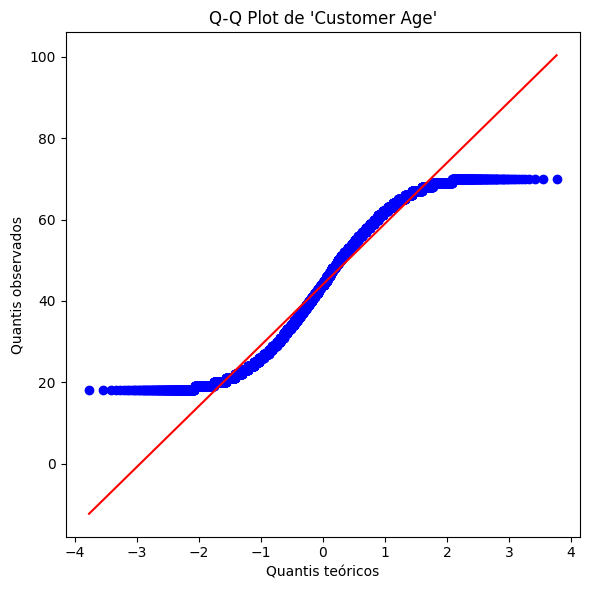

Assimetria             : -0.017172276314867847
Teste Shapiro-Wilk, p-valor:4.354657887088261e-37

Variável Customer Satisfaction Rating:


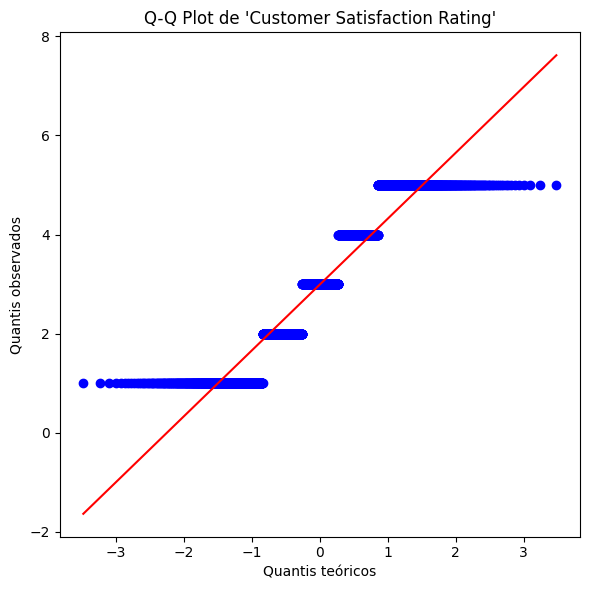

Assimetria             : 0.00837011540855382
Teste Shapiro-Wilk, p-valor:1.104626500064965e-40


In [125]:
alpha = 0.05
tamanho_maximo_shapiro = 5000
variaveis_numericas_relevantes = ['Customer Age', 'Customer Satisfaction Rating']
variaveis_normais = []
variaveis_nao_normais = []
resultados_normalidade = {}

print_formatado("1. Selecionar método de identificação de outlier:")


print_formatado("1.1. Q-Q Plot, Assimetria, Shapiro-Wilk")
for variavel in variaveis_numericas_relevantes:

    print(f"\nVariável {variavel}:")
    dados = df[variavel].dropna()
    plt.figure(figsize=(6, 6))

    stats.probplot(
        dados,
        dist="norm",
        plot=plt
    )

    plt.title(f"Q-Q Plot de '{variavel}'")
    plt.xlabel("Quantis teóricos")
    plt.ylabel("Quantis observados")
    plt.tight_layout()
    plt.show()

    assimetria = stats.skew(dados, bias=False, nan_policy="omit")
    print(f"Assimetria             : {assimetria}")

    # ---------------------------------------------------------
    # Teste de Shapiro-Wilk
    # ---------------------------------------------------------
    # Para amostras grandes, são selecionadas no máximo
    # 5.000 observações, pois o teste é muito sensível.
    if len(dados) > tamanho_maximo_shapiro:
        dados_teste = dados.sample(
            n=tamanho_maximo_shapiro,
            random_state=1
        )
    else:
        dados_teste = dados

    estatistica_w, p_valor = stats.shapiro(dados_teste)
    print(f"Teste Shapiro-Wilk, p-valor:{p_valor}")

### **1. Selecionar método de identificação de outlier**

* A variável `Ticket ID` não foi considerada por se tratar de um identificador único.
* Variável `Customer Age`:
  * O gráfico de Q-Q Plot observado não parece seguir os valores esperados para uma distribuição normal, existindo uma grande diferença nos pontos inferiores e superiores do gráfico, formando um "S". Ou seja, é um gráfico não-normal.
  * O valor de skew obtido foi -0,017172276314867847, um valor negativo muito próximo de zero indicando grande simetria.
  * O teste de Shapiro-Wilk retornou um p-valor muito abaixo de 0.05, indicando uma distribuição não-normal.
  * Devido ao resultado do Q-Q Plot e Shapiro-Wilk estaremos tratando essa distribuição como não-normal. Logo usaremos IRQ.

* Variável `Customer Satisfaction Rating`:
  * O gráfico de Q-Q Plot observado não parece seguir os valores esperados para uma distribuição normal, existindo uma grande diferença nos pontos inferiores e superiores do gráfico, formando um "S". Ou seja, é um gráfico não-normal.
  * O valor de skew obtido foi 0.00837011540855382, um valor positivo muito próximo de zero indicando grande simetria.
  * O teste de Shapiro-Wilk retornou um p-valor muito abaixo de 0.05, indicando uma distribuição não-normal.
  * Devido ao resultado do Q-Q Plot e Shapiro-Wilk estaremos tratando essa distribuição como não-normal. Logo usaremos IRQ.

In [126]:
variaveis_irq = variaveis_numericas_relevantes


print_formatado("2. Identificar outliers com IRQ ou Z-Score:")

outliers_por_coluna = {}
indices_outliers = set()

for coluna in variaveis_irq:
    dados = df[coluna].dropna()

    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_outliers = ((df[coluna] < limite_inferior) | (df[coluna] > limite_superior))
    outliers_coluna = df.loc[mascara_outliers].copy()
    outliers_por_coluna[coluna] = outliers_coluna
    indices_outliers.update(outliers_coluna.index)

    print(f"\nVariável: {coluna}")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Limite inferior: {limite_inferior:.2f}")
    print(f"Limite superior: {limite_superior:.2f}")
    print(f"Quantidade de outliers: {len(outliers_coluna)}")

    display(outliers_coluna[[coluna]].head(10))



2. Identificar outliers com IRQ ou Z-Score:

Variável: Customer Age
Q1: 31.00
Q3: 57.00
IQR: 26.00
Limite inferior: -8.00
Limite superior: 96.00
Quantidade de outliers: 0


,Customer Age



Variável: Customer Satisfaction Rating
Q1: 2.00
Q3: 4.00
IQR: 2.00
Limite inferior: -1.00
Limite superior: 7.00
Quantidade de outliers: 0


,Customer Satisfaction Rating


### **2. Identificar outliers com IRQ ou ZScore**

* Não foram identificados nenhum outlier para as variáveis `Customer Age` e `Customer Satisfaction Rating`, pois seus valores de limite inferior e superior estão fora do intervalo de valores mínimos e máximos observados. Portanto não será necessário realizar nenhuma remoção de outliers.

## **Variáveis Categóricas**

In [127]:
nivel_desequilibrio = 2
limite_categoria_rara = 0.01

print_formatado("1. Identificar categorias raras:")
for variavel in variaveis_categoricas:
    if variavel == variavel_alvo:
      continue

    frequencia_relativa = df[variavel].value_counts(
        normalize=True,
        dropna=False
    )

    categorias_raras = frequencia_relativa[
        frequencia_relativa < limite_categoria_rara
    ]

    print(f"\nCategorias raras da variável '{variavel}':")

    if categorias_raras.empty:
        print("Nenhuma categoria rara encontrada.")
    else:
        print((categorias_raras * 100).round(2).astype(str) + "%")


print_formatado("2. Identificar possível desiquilíbrio entre classes:")
for variavel in variaveis_categoricas:
    if variavel == variavel_alvo:
      continue

    contagem = df[variavel].value_counts(dropna=False)

    maior_frequencia = contagem.max()
    menor_frequencia = contagem.min()
    razao_desequilibrio = maior_frequencia / menor_frequencia

    print(f"\nVariável '{variavel}':")
    print(f"Maior frequência: {maior_frequencia}")
    print(f"Menor frequência: {menor_frequencia}")
    print(f"Razão maior/menor frequência: {razao_desequilibrio:.2f}")

    if razao_desequilibrio >= nivel_desequilibrio:
        print("Conclusão: Possível desequilíbrio.")
    else:
        print("Conclusão: Sem desequilíbrio.")



1. Identificar categorias raras:

Categorias raras da variável 'Customer Gender':
Nenhuma categoria rara encontrada.

Categorias raras da variável 'Product Purchased':
Nenhuma categoria rara encontrada.

Categorias raras da variável 'Ticket Type':
Nenhuma categoria rara encontrada.

Categorias raras da variável 'Ticket Status':
Nenhuma categoria rara encontrada.

Categorias raras da variável 'Ticket Priority':
Nenhuma categoria rara encontrada.

Categorias raras da variável 'Ticket Channel':
Nenhuma categoria rara encontrada.


2. Identificar possível desiquilíbrio entre classes:

Variável 'Customer Gender':
Maior frequência: 2896
Menor frequência: 2686
Razão maior/menor frequência: 1.08
Conclusão: Sem desequilíbrio.

Variável 'Product Purchased':
Maior frequência: 240
Menor frequência: 178
Razão maior/menor frequência: 1.35
Conclusão: Sem desequilíbrio.

Variável 'Ticket Type':
Maior frequência: 1752
Menor frequência: 1634
Razão maior/menor frequência: 1.07
Conclusão: Sem desequilíb

### **Observações Identificar Outliers e anomalias**

**Observação:** A variável `Ticket Subject` não foi considerada por se tratar da variável alvo.

* Nas variáveis categóricas análisadas não foram encontradas categorias raras.
* Também não foram observados desequilíbrios significativos na distribuição das categorias dessas variáveis.

## **Variáveis textuais**

**Observação:** Das variáveis textuais só analisamos os valores das variáveis `Ticket Description` e `Resolution`. Pois as variáveis `Customer Name`, `Customer Email` se referem apenas a dados de identificação do cliente, não tendo relação deterministica com o `Ticket Subject`.



1. Criar/identificar variáveis numéricas a partir da variável textual - Ticket Description:
             Ticket Subject  Ticket Description_qtd_palavras  \
0             Product setup                               43   
1  Peripheral compatibility                               44   
2           Network problem                               42   
3            Account access                               41   
4                 Data loss                               55   

   Ticket Description_tamanho  Ticket Description_qtd_termos_distintos  
0                         269                                       24  
1                         264                                       16  
2                         256                                       18  
3                         249                                       21  
4                         319                                       24  

Estatísticas:
       Ticket Description_qtd_palavras  Ticket Description_tamanho  

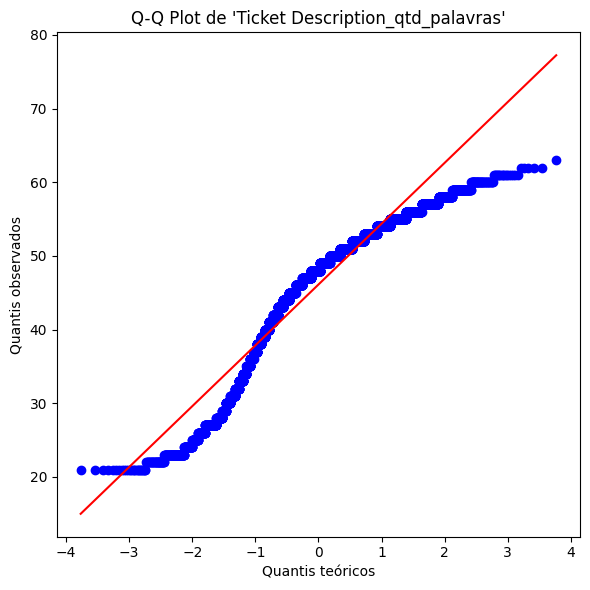

Assimetria             : -0.9780888369713527
Teste Shapiro-Wilk, p-valor:2.0175124432708326e-46

Variável Ticket Description_tamanho:


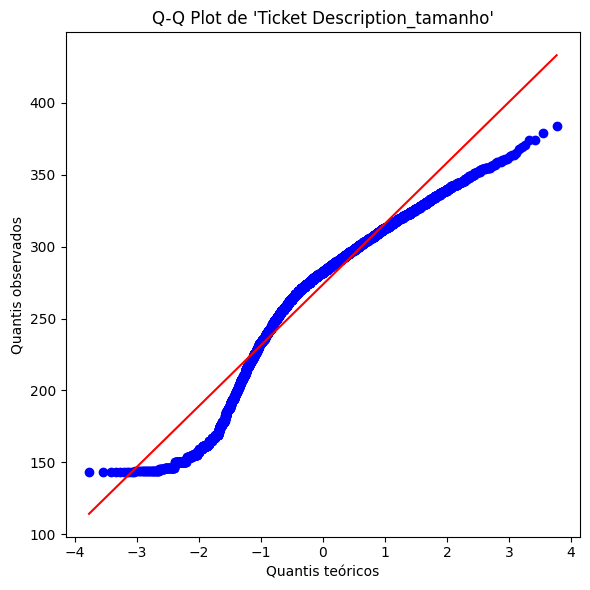

Assimetria             : -0.9808961561797191
Teste Shapiro-Wilk, p-valor:1.0515797796853072e-43

Variável Ticket Description_qtd_termos_distintos:


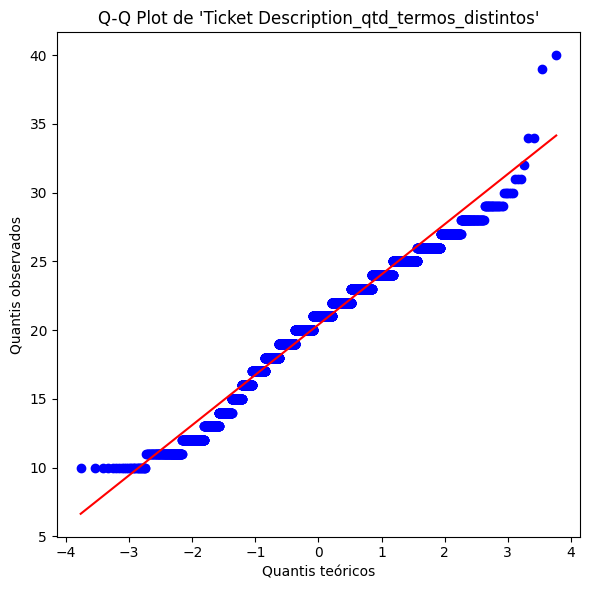

Assimetria             : -0.43210711946906505
Teste Shapiro-Wilk, p-valor:2.2194561959671675e-30


1. Criar/identificar variáveis numéricas a partir da variável textual - Resolution:
             Ticket Subject  Resolution_qtd_palavras  Resolution_tamanho  \
0             Product setup                     <NA>                <NA>   
1  Peripheral compatibility                     <NA>                <NA>   
2           Network problem                        7                  43   
3            Account access                        7                  44   
4                 Data loss                        4                  26   

   Resolution_qtd_termos_distintos  
0                                0  
1                                0  
2                                5  
3                                5  
4                                4  

Estatísticas:
       Resolution_qtd_palavras  Resolution_tamanho  \
count                   2769.0              2769.0   
mean           

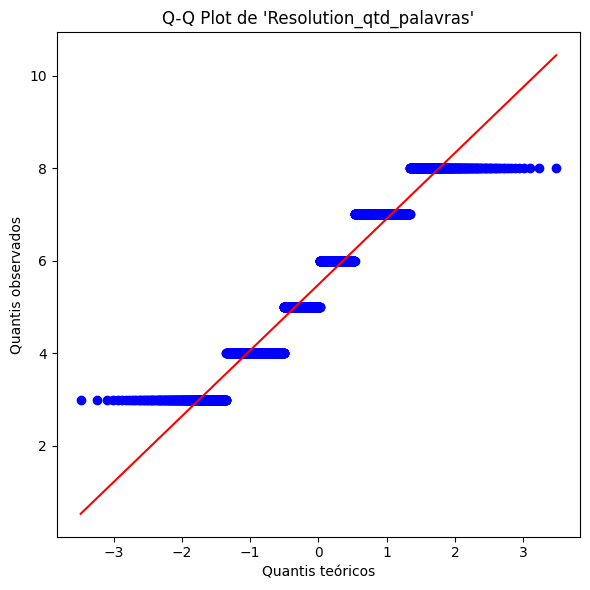

Assimetria             : 0.026132713383096293
Teste Shapiro-Wilk, p-valor:9.624835798396901e-35

Variável Resolution_tamanho:


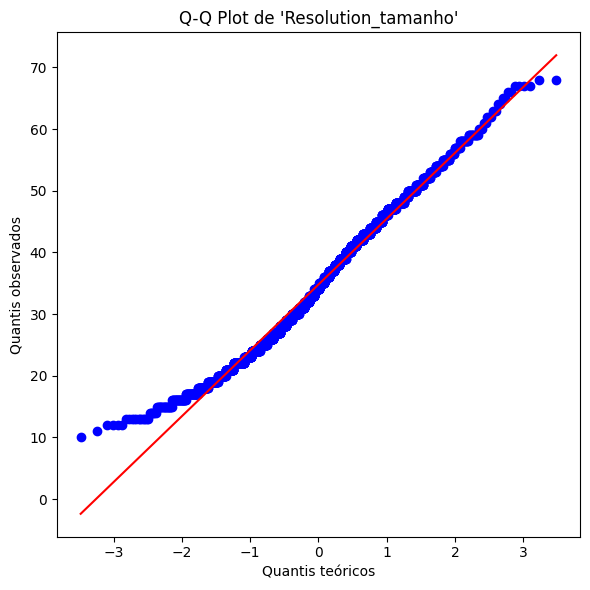

Assimetria             : 0.22803311986393038
Teste Shapiro-Wilk, p-valor:4.025145947176533e-15

Variável Resolution_qtd_termos_distintos:


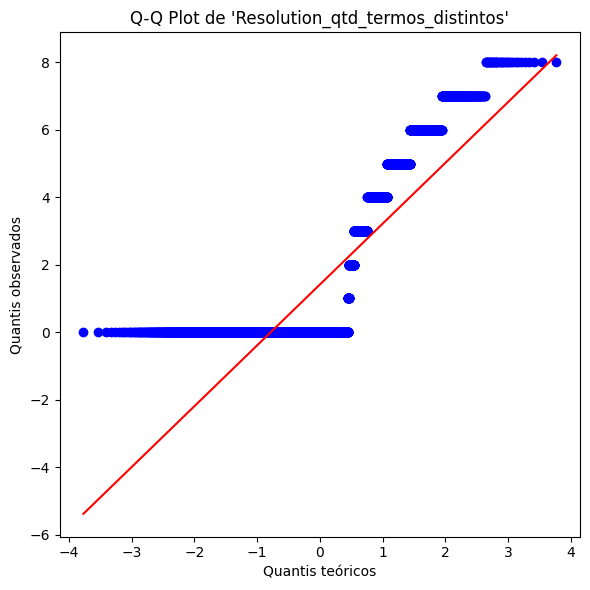

Assimetria             : 1.185253702538645
Teste Shapiro-Wilk, p-valor:2.7162009227852707e-71


In [128]:
for variavel in variaveis_textuais_com_tratamento:
  print_formatado(f"1. Criar/identificar variáveis numéricas a partir da variável textual - {variavel}:")
  X_vetorizado = matrizes_vetorizadas[variavel]
  df[f"{variavel}_qtd_termos_distintos"] = ((X_vetorizado > 0).sum(axis=1).A1)
  df[f"{variavel}_qtd_termos_distintos"] = df[f"{variavel}_qtd_termos_distintos"].astype("Int64")
  variaveis_numericas_by_textual = [f"{variavel}_qtd_palavras", f"{variavel}_tamanho", f"{variavel}_qtd_termos_distintos"]
  print(df[[variavel_alvo] + variaveis_numericas_by_textual].head())
  print("\nEstatísticas:")
  print(df[variaveis_numericas_by_textual].describe())
  print()

  print_formatado("1.2. Selecionar método de identificação de outlier:")
  print_formatado("1.2.1. Q-Q Plot, Assimetria, Shapiro-Wilk")

  colunas_numericas = variaveis_numericas_by_textual
  alpha = 0.05
  tamanho_maximo_shapiro = 5000

  for coluna in colunas_numericas:

      print(f"\nVariável {coluna}:")
      dados = df[coluna].dropna()
      plt.figure(figsize=(6, 6))

      stats.probplot(
          dados,
          dist="norm",
          plot=plt
      )

      plt.title(f"Q-Q Plot de '{coluna}'")
      plt.xlabel("Quantis teóricos")
      plt.ylabel("Quantis observados")
      plt.tight_layout()
      plt.show()

      assimetria = stats.skew(dados, bias=False, nan_policy="omit")
      print(f"Assimetria             : {assimetria}")

      # ---------------------------------------------------------
      # Teste de Shapiro-Wilk
      # ---------------------------------------------------------
      # Para amostras grandes, são selecionadas no máximo
      # 5.000 observações, pois o teste é muito sensível.
      if len(dados) > tamanho_maximo_shapiro:
          dados_teste = dados.sample(
              n=tamanho_maximo_shapiro,
              random_state=1
          )
      else:
          dados_teste = dados

      estatistica_w, p_valor = stats.shapiro(dados_teste)
      print(f"Teste Shapiro-Wilk, p-valor:{p_valor}")

### **1. Selecionar método de identificação de outlier**


* Variável `Ticket Description_qtd_palavras`:
  * O gráfico de Q-Q Plot observado não parece seguir os valores esperados para uma distribuição normal, existindo uma grande diferença nos pontos inferiores e superiores do gráfico, formando um "S". Ou seja, é um gráfico não-normal.
  * O valor de skew obtido foi -0.9780888369713527, um valor negativo que indica uma assimetria moderada.
  * O teste de Shapiro-Wilk retornou um p-valor muito abaixo de 0.05, indicando uma distribuição não-normal.
  * Devido ao resultado do Q-Q Plot e Shapiro-Wilk estaremos tratando essa distribuição como não-normal. Logo usaremos IRQ.

* Variável `Ticket Description_tamanho`:
  * O gráfico de Q-Q Plot observado não parece seguir os valores esperados para uma distribuição normal, existindo uma grande diferença nos pontos inferiores e superiores do gráfico, formando um "S". Ou seja, é um gráfico não-normal.
  * O valor de skew obtido foi -0.9808961561797191, um valor negativo que indica uma assimetria moderada.
  * O teste de Shapiro-Wilk retornou um p-valor muito abaixo de 0.05, indicando uma distribuição não-normal.
  * Devido ao resultado do Q-Q Plot e Shapiro-Wilk estaremos tratando essa distribuição como não-normal. Logo usaremos IRQ.


* Variável `Ticket Description_qtd_termos_distintos`:
  * O gráfico de Q-Q Plot observado não parece seguir os valores esperados para uma distribuição normal, existindo uma grande diferença nos pontos inferiores e superiores do gráfico, formando um "S". Ou seja, é um gráfico não-normal.
  * O valor de skew obtido foi -0.43210711946906505, um valor negativo que indica simetria, estando dentro da faixa de -0.5 e 0.5.
  * O teste de Shapiro-Wilk retornou um p-valor muito abaixo de 0.05, indicando uma distribuição não-normal.
  * Devido ao resultado do Q-Q Plot e Shapiro-Wilk estaremos tratando essa distribuição como não-normal. Logo usaremos IRQ.

* Variável `Resolution_qtd_palavras`:
  * O gráfico de Q-Q Plot observado não parece seguir os valores esperados para uma distribuição normal, existindo uma grande diferença nos pontos inferiores e superiores do gráfico, formando um "S". Ou seja, é um gráfico não-normal.
  * O valor de skew obtido foi 0.026132713383096293, um valor positivo que indica simetria, estando dentro da faixa de -0.5 e 0.5.
  * O teste de Shapiro-Wilk retornou um p-valor muito abaixo de 0.05, indicando uma distribuição não-normal.
  * Devido ao resultado do Q-Q Plot e Shapiro-Wilk estaremos tratando essa distribuição como não-normal. Logo usaremos IRQ.

* Variável `Resolution_tamanho`:
  * O gráfico de Q-Q Plot observado não parece seguir os valores esperados para uma distribuição normal, existindo uma grande diferença nos pontos inferiores e superiores do gráfico, formando um "S". Ou seja, é um gráfico não-normal.
  * O valor de skew obtido foi 0.22803311986393038, um valor positivo que indica simetria, estando dentro da faixa de -0.5 e 0.5.
  * O teste de Shapiro-Wilk retornou um p-valor muito abaixo de 0.05, indicando uma distribuição não-normal.
  * Devido ao resultado do Q-Q Plot e Shapiro-Wilk estaremos tratando essa distribuição como não-normal. Logo usaremos IRQ.

* Variável `Resolution_qtd_termos_distintos`:
  * O gráfico de Q-Q Plot observado não parece seguir os valores esperados para uma distribuição normal, existindo uma grande diferença nos pontos inferiores e superiores do gráfico, formando um "S". Ou seja, é um gráfico não-normal.
  * O valor de skew obtido foi 1.185253702538645, um valor positivo que indica assimetria forte, acima de 1.
  * O teste de Shapiro-Wilk retornou um p-valor muito abaixo de 0.05, indicando uma distribuição não-normal.
  * Devido ao resultado do Q-Q Plot e Shapiro-Wilk estaremos tratando essa distribuição como não-normal. Logo usaremos IRQ.


In [129]:
variaveis_irq = []
for variavel in variaveis_textuais_com_tratamento:
  variaveis_irq.extend([f"{variavel}_qtd_palavras", f"{variavel}_tamanho", f"{variavel}_qtd_termos_distintos"])


print_formatado("2. Identificar outliers com IRQ ou Z-Score:")

outliers_por_coluna = {}
indices_outliers = set()

for coluna in variaveis_irq:
    dados = df[coluna].dropna()

    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_outliers = ((df[coluna] < limite_inferior) | (df[coluna] > limite_superior))
    outliers_coluna = df.loc[mascara_outliers].copy()
    outliers_por_coluna[coluna] = outliers_coluna
    indices_outliers.update(outliers_coluna.index)

    print(f"\nVariável: {coluna}")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Limite inferior: {limite_inferior:.2f}")
    print(f"Limite superior: {limite_superior:.2f}")
    print(f"Quantidade de outliers: {len(outliers_coluna)}")

    display(outliers_coluna[[variavel_alvo, coluna]].head())


print_formatado("3. Identificação de termos raros:")
for variavel in variaveis_textuais_com_tratamento:
  print_formatado(f"Variável - {variavel}:")
  X_vetorizado = matrizes_vetorizadas[variavel]
  vocabulario = vocabularios[variavel]
  frequencia_documentos = ((X_vetorizado > 0).sum(axis=0).A1)
  df_termos = pd.DataFrame({"palavra": vocabulario,"qtd_documentos": frequencia_documentos})
  df_termos = df_termos.sort_values("qtd_documentos",ascending=True)
  print("Termos menos frequentes:")
  display(df_termos.head(10))



2. Identificar outliers com IRQ ou Z-Score:

Variável: Ticket Description_qtd_palavras
Q1: 42.00
Q3: 52.00
IQR: 10.00
Limite inferior: 27.00
Limite superior: 67.00
Quantidade de outliers: 306


,Ticket Subject,Ticket Description_qtd_palavras
52,Network problem,25
94,Account access,25
105,Battery life,23
106,Installation support,22
107,Account access,23



Variável: Ticket Description_tamanho
Q1: 254.00
Q3: 303.00
IQR: 49.00
Limite inferior: 180.50
Limite superior: 376.50
Quantidade de outliers: 487


,Ticket Subject,Ticket Description_tamanho
52,Network problem,158
56,Software bug,175
105,Battery life,144
106,Installation support,145
107,Account access,155



Variável: Ticket Description_qtd_termos_distintos
Q1: 18.00
Q3: 23.00
IQR: 5.00
Limite inferior: 10.50
Limite superior: 30.50
Quantidade de outliers: 34


...

,Ticket Subject,Resolution_qtd_termos_distintos
98,Refund request,8
338,Product compatibility,8
375,Refund request,8
913,Battery life,8
1212,Installation support,8




3. Identificação de termos raros:


Variável - Ticket Description:
Termos menos frequentes:


,palavra,qtd_documentos
3874,httpstwittercomjohanstatus1003027354588449627,1
3897,httpswwwgonzalocomproductproduct273080,1
3898,httpswwwgoodbylindbohcomproductspurchasedhtml,1
3899,httpswwwkickstartercomprojects27395520thesuper...,1
3867,httpstcorezvx0gxmf,1
3868,httpstcoxdyj,1
3869,httpstcozg2x2sm3d8i,1
3870,httpstrackermvmicrosoftcom,1
3871,httpstwittercomhashtaghashtaghashtagrefresh_bu...,1
3872,httpstwittercomhipkicks1,1




Variável - Resolution:
Termos menos frequentes:


,palavra,qtd_documentos
479,picture,5
508,process,6
591,security,6
175,difference,6
676,talk,7
157,data,7
538,realize,7
760,year,7
17,agent,7
655,store,7


### **2. Identificar outliers com IRQ ou ZScore**

* Variável `Ticket Description_qtd_palavras`:
  * Foram encontradas 306 ocorrências de outliers para essa variável. Considerando valores abaixo de 27 e acima de 67.

* Variável `Ticket Description_tamanho`:
  * Foram encontradas 487 ocorrências de outliers para essa variável. Considerando valores abaixo de 180,50 e acima de 376,50. Como a quantidade de caracteres é inteira e positiva, mensagens com tamanho abaixo de 181 ou acima de 377 caracteres.

* Variável `Ticket Description_qtd_termos_distintos`:
  * Foram encontradas 34 ocorrências de outliers para essa variável. Considerando valores abaixo de 10,50 e acima de 30,50. Como a quantidade de caracteres é inteira e positiva, mensagens com tamanho abaixo de 11 ou acima de 31 caracteres.

* Variável `Resolution_qtd_palavras`:
  * Não foram encontrados nenhum outlier para essa variável

* Variável `Resolution_tamanho`:
  * Não foram encontrados nenhum outlier para essa variável

* Variável `Resolution_qtd_termos_distintos`:
  * Foram encontradas 35 ocorrências de outliers para essa variável. Considerando valores abaixo de -4,50 e acima de 7,50. Como a quantidade de palavras é inteira e positiva, mensagens com 8 palavras ou mais são consideradas outliers.

### **3. Identificar termos raros**

* Variável `Ticket Description`:
  * Parte desses termos apresenta indícios de erros em nossa sanitização ou erros de digitação do usuário, pois aparentam ser sites que sofreram tratamentos de caracteres especiais ou pontuação, ex: `httpstwittercomjohanstatus1003027354588449627`, `httpswwwgonzalocomproductproduct273080` e `httpswwwgoodbylindbohcomproductspurchasedhtml`
  * Optou-se por não remover automaticamente os termos raros ou os registros que apresentam esse tipo de formatação, pois sua baixa frequência ou aparência incomum não é, por si só, suficiente para determinar que sejam dados inválidos. Dessa forma, os registros são mantidos para evitar a perda potencial de informações durante o processo de limpeza.

* Variável `Resolution`:
  * Existem termos raros aparentemente válidos, como `picture` e `process`. Logo, uma baixa frequência não significa necessariamente que o termo seja incorreto.
  * Optou-se por não remover automaticamente os termos raros, pois sua baixa frequência ou aparência incomum não é, por si só, suficiente para determinar que sejam dados inválidos. Dessa forma, os registros são mantidos para evitar a perda potencial de informações durante o processo de limpeza.

# **Teste de Hipótese**

## **Identificação de hipótese**

### Hipótese 1

#### Hipótese nula (H₀)

A nota média de satisfação (`Customer Satisfaction Rating`), não apresenta diferença estatisticamente significativa entre dois `Ticket Subject`.

#### Hipótese alternativa (H₁)

A nota média de satisfação (`Customer Satisfaction Rating`), apresenta diferença estatisticamente significativa entre dois `Ticket Subject`, por exemplo: `Refund request` e `Software bug`.

#### Nível de significância

Será adotado um nível de significância de **5% (α = 0,05)**.

- Se `p < 0,05`,  H₀ rejeitada.
- Se `p ≥ 0,05`, H₀ não rejeitada.

#### Método de Teste de Hipótese escolhido:

Será utilizado o teste t de Welch, pois estamos tentando analisar se a média de uma variável numérica (`Customer Satisfaction Rating`) é diferente entre dois grupos (`Ticket Subject`).

### Conclusão da hipótese:

Com base no teste t de Welch, foi obtido um p-valor 0.8771151762290477, como foi um valor ≥ 0.05 não podemos rejeitar a hipótese nula. Porém, isso também não confirma que a hipótese nula seja verdadeira.


In [130]:
subject_1 = "Refund request"
subject_2 = "Software bug"

grupo1 = df[df[variavel_alvo] == subject_1]["Customer Satisfaction Rating"].dropna()
grupo2 = df[df[variavel_alvo] == subject_2]["Customer Satisfaction Rating"].dropna()
estatistica, p_valor = stats.ttest_ind(grupo1, grupo2,equal_var=False)

print_formatado(f"Teste t de Welch para os grupos '{subject_1}' e '{subject_2}' da variável {variavel_alvo} e 'Customer Satisfaction Rating':")
print(f"{subject_1}:")
print("Quantidade de exemplos:", len(grupo1))
print("Média:", grupo1.mean())
print()
print(f"{subject_2}:")
print("Quantidade de exemplos:", len(grupo2))
print("Média:", grupo2.mean())
print()
print("Estatística t:", estatistica)
print("p-valor:", p_valor)



Teste t de Welch para os grupos 'Refund request' e 'Software bug' da variável Ticket Subject e 'Customer Satisfaction Rating':
Refund request:
Quantidade de exemplos: 178
Média: 3.067415730337079

Software bug:
Quantidade de exemplos: 199
Média: 3.0452261306532664

Estatística t: 0.1547344159027334
p-valor: 0.8771151762290477


### Hipótese 2

#### Hipótese nula (H₀)

A nota média de satisfação (`Customer Satisfaction Rating`) não difere entre prioridades (`Ticket Priority`) urgentes (Critical/HIGH) e não urgentes (Medium/LOW)?

#### Hipótese alternativa (H₁)

A nota média de satisfação (`Customer Satisfaction Rating`) difere entre prioridades (`Ticket Priority`) urgentes (Critical/HIGH) e não urgentes (Medium/LOW)?

#### Nível de significância

Será adotado um nível de significância de **5% (α = 0,05)**.

- Se `p < 0,05`,  H₀ rejeitada.
- Se `p ≥ 0,05`, H₀ não rejeitada.

#### Método de Teste de Hipótese escolhido:

Será utilizado o teste t de Welch, pois estamos tentando analisar se a média de uma variável numérica (`Customer Satisfaction Rating`) é diferente entre dois grupos (`Ticket Priority`).

### Conclusão da hipótese:

Com base no teste t de Welch, foi obtido um p-valor 0.4234214765428054, como foi um valor ≥ 0.05 não podemos rejeitar a hipótese nula. Porém, isso também não confirma que a hipótese nula seja verdadeira.



In [131]:
print(df["Ticket Priority"].unique())

grupo_urgente = df[(df["Ticket Priority"] == "Critical") | (df["Ticket Priority"] == "High") ]["Customer Satisfaction Rating"].dropna()
grupo_nao_urgente = df[(df["Ticket Priority"] == "Medium") | (df["Ticket Priority"] == "Low")]["Customer Satisfaction Rating"].dropna()
estatistica, p_valor = stats.ttest_ind(grupo_urgente, grupo_nao_urgente,equal_var=False)

print_formatado(f"Teste t de Welch para os grupos 'Urgente' e 'Não Urgente' da variável 'Ticket Priority' e 'Customer Satisfaction Rating':")
print(f"Urgente:")
print("Quantidade de exemplos:", len(grupo_urgente))
print("Média:", grupo_urgente.mean())
print()
print(f"Não Urgente:")
print("Quantidade de exemplos:", len(grupo_nao_urgente))
print("Média:", grupo_nao_urgente.mean())
print()
print("Estatística t:", estatistica)
print("p-valor:", p_valor)

['Critical', 'Low', 'High', 'Medium']
Categories (4, object): ['Critical', 'High', 'Low', 'Medium']


Teste t de Welch para os grupos 'Urgente' e 'Não Urgente' da variável 'Ticket Priority' e 'Customer Satisfaction Rating':
Urgente:
Quantidade de exemplos: 1431
Média: 2.970649895178197

Não Urgente:
Quantidade de exemplos: 1338
Média: 3.013452914798206

Estatística t: -0.800618341386452
p-valor: 0.4234214765428054


# **Conclusões**

* A base possuía **8.469 registros** e **17 colunas**, não teve remoção de duplicatas, portanto manteve-se **8.469 registros**, porém houve adição de novas colunas totalizando-se **27 colunas**.

* Foram encontrados valores nulos explícitos nas colunas: `Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating`.

  * Resolution (5.700 valores ausentes): O volume de dados faltantes corresponde exatamente aos tickets em andamento (Open e Pending Customer Response). Trata-se de uma ausência estrutural, visto que a resolução só é documentada no encerramento do chamado.


  * First Response Time (2.819 valores ausentes): A quantidade de registros nulos espelha o total exato de tickets com status Open, evidenciando que estes chamados ainda aguardam a primeira interação da equipe de suporte.


  * Time to Resolution (5.700 valores ausentes): De forma análoga à coluna Resolution, a ausência de dados decorre de tickets que ainda não cumpriram seu ciclo de vida completo.

  *  Customer Satisfaction Rating (5.700 valores ausentes): A omissão de dados é justificada pela regra de negócio, já que a pesquisa de Customer Satisfaction é acionada apenas após o fechamento do atendimento.

  * Não existiu a necessidade de tratar os valores ausentes, pois no contexto do dataset os mesmos fazem sentido. Eles indicam que o ticket está em um estado "aberto". Como é o exemplo dos registros ausentes da coluna `Resolution`.

* A variável alvo `Ticket Subject` representa o assunto ou tópico do ticket. (ex.: `Product setup`, `Peripheral compatibility`, `etc`). `variável categorica`.

* Conclusão Análise Univariada

  * As variáveis numéricas `Customer Age` e `Customer Satisfaction Rating` não apresentam distribuição normal, elas apresentam uma distribuição homogênea.

  * As variáveis categóricas `Customer Gender`, `Product Purchased`, `Ticket Type`, `Ticket Status`, `Ticket Priority` e `Ticket Channel` não apresentam distribuição normal, elas apresentam uma distribuição relativamente homogênea, embora haja um certo desnível o mesmo ainda é pequeno em relação aos dados.

  * As variáveis numéricas de quantidade de palavras e tamanho de palavras, relacionadas à variável textual `Ticket Description`, apresentam distribuição assimétrica à esquerda. Já as variáveis numéricas relacionadas à variável textual `Resolution`, apresentam distribuição em formato de sino, distribuição normal.

* Conclusão Análise Multivariada

  * As variáveis numéricas não apresentaram valores de correlação significativos com a variável alvo, não demonstrando existência de uma variável preditora. E também, não apresentaram valores de correlação significativos entre si, não demonstrado existência de variável redundante.

  * As variáveis categóricas não apresentaram valores de associação significativos com a variável alvo, apresentaram p-valor ≥ 0,05 no teste de Qui-quadrado e valores de V de Cramér abaixo de 0,1, não demonstrando existência de uma variável preditora. E também, não apresentaram valores de correlação significativos entre si, não demonstrado existência de variável redundante.

  * As variáveis textuais apresentaram termos com associação estatisticamente significativa com a variável alvo, porém não foi possível identificar uma relação clara entre os termos e as categorias do alvo, além de terem sido identificados possíveis termos redundantes e ruídos que devem ser avaliados antes de sua utilização como variáveis preditoras.

* Conclusão Outliers e Anomalias

  * As variáveis numéricas `Customer Age` e `Customer Satisfaction Rating` foram determinadas como não-normais, e para sua respectivas análises de outliers e anomalias foi utilizado o método IRQ, o qual não encontrou nenhum registro outlier para essas variáveis.

  * As variáveis categóricas análisadas não apresentaram categorias raras e também não foram observados desequilíbrios significativos na distribuição das categorias dessas variáveis.

  * As variáveis textuais apresentaram termos raros, porém optou-se por não realizar nenhuma remoção, pois sua baixa frequência ou aparência incomum não é, por si só, suficiente para determinar que sejam dados inválidos. Dessa forma, os registros são mantidos para evitar a perda potencial de informações durante o processo de limpeza.